<a href="https://colab.research.google.com/github/vdrakopoulou/vdrakopoulou/blob/main/ESG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Some input files are missing. Please provide `05_panel_dataset.csv` and `announcements_export.csv` to run the script.

In [16]:
%%writefile run_event_study_regressions.py
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from pathlib import Path

def main():
    import argparse
    import os

    parser = argparse.ArgumentParser(description="Run event study regressions.")
    parser.add_argument('--event_panel', type=str, required=True, help="Path to the event study dataset CSV file.")
    parser.add_argument('--outdir', type=str, default='event_outputs', help="Output directory for results.")
    parser.add_argument('--exclude_earn_overlap', action='store_true', help="Exclude events that overlap with earnings announcements.")
    args = parser.parse_args()

    os.makedirs(args.outdir, exist_ok=True)

    df = pd.read_csv(args.event_panel)

    # Ensure date column is datetime if it exists and is not already
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])

    # Dynamically find column names
    event_id_col = "event_id"
    rel_day_col = "rel_day"
    abret_col = "abret"
    ticker_col = "symbol" # As per build_event_study_dataset.py output

    # Check if essential columns exist
    required_cols = [event_id_col, rel_day_col, abret_col, ticker_col]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"event_panel is missing columns: {sorted(missing)}")

    # 1. Simple Average Abnormal Returns
    print("Calculating mean abnormal returns by relative day...")
    mean_abret_by_rel_day = df.groupby(rel_day_col)[abret_col].agg(['mean', 'count', 'std']).reset_index()
    mean_abret_by_rel_day['se'] = mean_abret_by_rel_day['std'] / np.sqrt(mean_abret_by_rel_day['count'])
    mean_abret_by_rel_day.rename(columns={'mean': 'mean', 'std': 'std'}, inplace=True)
    mean_abret_by_rel_day.to_csv(Path(args.outdir) / 'mean_abret_by_rel_day.csv', index=False)
    print(f"Saved: {Path(args.outdir) / 'mean_abret_by_rel_day.csv'}")

    # 2. Regression-based Event Study
    # Define the regression formula dynamically
    formula = f'{abret_col} ~ C({rel_day_col}, Treatment(reference=-1)) + C({event_id_col})'

    # Fit the OLS model with clustered standard errors
    # We need to make sure 'ticker' is available for clustering, if not, use 'event_id'
    if ticker_col in df.columns:
        groups = df[ticker_col]
    else:
        groups = df[event_id_col]

    print("Running OLS regression with clustered standard errors...")
    model = ols(formula, data=df)
    # Using cluster robust standard errors (e.g., clustered by firm/ticker)
    results = model.fit(cov_type='cluster', cov_kwds={'groups': groups})

    # Save regression results summary
    results_summary_path = Path(args.outdir) / 'event_study_results.txt'
    with open(results_summary_path, 'w') as f:
        f.write(results.summary().as_text())
    print(f"Saved: {results_summary_path}")

    # Save coefficients to a CSV
    coefficients_path = Path(args.outdir) / 'event_study_coefficients.csv'
    results.summary2().tables[1].to_csv(coefficients_path)
    print(f"Saved: {coefficients_path}")

    # 3. Cumulative Abnormal Returns (CAR) for specific windows
    # Function to calculate CAR for a given window
    def car_window(d, a, b):
        sub = d[(d[rel_day_col] >= a) & (d[rel_day_col] <= b)].copy()
        car = sub.groupby(event_id_col)[abret_col].sum()
        return car

    windows = [(-1,1), (-3,3), (-5,5), (-10,10)]
    rows = []

    print("Calculating CAR for various windows...")
    for a,b in windows:
        car = car_window(df, a, b).dropna()
        mean = car.mean()
        med = car.median()
        n = car.shape[0]

        # Perform t-test
        tstat, pval = stats.ttest_1samp(car, 0.0, nan_policy="omit")

        # Perform Wilcoxon signed-rank test
        wstat, wp = (np.nan, np.nan) # Initialize in case n=0
        if n > 0 and len(car) > 0:
            try:
                wstat, wp = stats.wilcoxon(car, alternative="two-sided")
            except ValueError: # Handle cases where all values are the same for wilcoxon
                wstat, wp = np.nan, np.nan

        rows.append({
            "window": f"[{a},{b}]",
            "N_events": n,
            "Mean_CAR": mean,
            "Median_CAR": med,
            "t_stat": tstat,
            "p_value_t": pval,
            "wilcoxon_stat": wstat,
            "p_value_w": wp
        })

    car_table = pd.DataFrame(rows)
    car_table.to_csv(Path(args.outdir) / 'CAR_summary_windows.csv', index=False)
    print(f"Saved: {Path(args.outdir) / 'CAR_summary_windows.csv'}")

    print("Event study analysis complete.")

if __name__ == '__main__':
    main()

Overwriting run_event_study_regressions.py


In [ ]:
pip install pandas openpyxl

In [47]:
import pandas as pd
import numpy as np
from pathlib import Path

def read_earnings(earnings_path: Path) -> pd.DataFrame:
    """Reads the earnings file and performs necessary preprocessing."""
    earnings_df = pd.read_csv(str(earnings_path)) # Explicitly convert Path to string

    # Attempt to identify the date column
    potential_date_cols = ['date', 'report_date', 'announcement_date', 'year']
    date_col = None
    for col in potential_date_cols:
        if col in earnings_df.columns:
            try:
                # Attempt to convert to datetime. This will fail if the column
                # is not in a convertible format or if it contains mixed types.
                earnings_df[col] = pd.to_datetime(earnings_df[col])
                date_col = col
                break
            except Exception:
                # If conversion fails for a candidate column, it might not be the date column.
                continue

    if date_col is None:
        raise ValueError("Earnings file must contain a date/datetime column (e.g., 'date', 'report_date', 'announcement_date', or 'year')")

    # Rename the identified date column to 'date' for consistency
    earnings_df.rename(columns={date_col: 'date'}, inplace=True)

    # Ensure 'date' column is datetime and sort
    earnings_df['date'] = pd.to_datetime(earnings_df['date'])
    earnings_df.sort_values(by=['ticker', 'date'], inplace=True)
    return earnings_df


def read_panel(panel_path: Path) -> pd.DataFrame:
    """Reads the panel dataset."""
    panel_df = pd.read_csv(str(panel_path)) # Explicitly convert Path to string
    panel_df['date'] = pd.to_datetime(panel_df['datetime'])
    panel_df.set_index(['ticker', 'date'], inplace=True)
    return panel_df


def read_events(events_path: Path) -> pd.DataFrame:
    """Reads the events list."""
    events_df = pd.read_excel(str(events_path))
    events_df['announcement_date'] = pd.to_datetime(events_df['Announcement Date'])
    return events_df


def get_trading_day_on_or_after(date: pd.Timestamp, trading_days: pd.Series) -> pd.Timestamp:
    """Finds the first trading day on or after a given date."""
    # Ensure trading_days is sorted and unique
    trading_days_sorted = trading_days.sort_values().unique()

    # Find the index of the first trading day >= date
    idx = np.searchsorted(trading_days_sorted, date)

    if idx < len(trading_days_sorted):
        return trading_days_sorted[idx]
    else:
        return pd.NaT  # No trading day found on or after the given date


def calculate_car(returns_df: pd.DataFrame, window: int) -> pd.DataFrame:
    """Calculates Cumulative Abnormal Returns (CAR)."""
    # Assuming returns_df has 'abnormal_return' and is indexed by date
    car = returns_df['abnormal_return'].rolling(window=window, min_periods=1).sum()
    return car.to_frame(name=f'CAR_{window}')


def main():
    import argparse
    import os

    parser = argparse.ArgumentParser(description="Build event study dataset.")
    parser.add_argument('--events', type=str, required=True, help="Path to the Excel file containing the list of events.")
    parser.add_argument('--panel', type=str, required=True, help="Path to the CSV file containing the panel dataset (stock returns, market returns, etc.).")
    parser.add_argument('--earnings', type=str, required=True, help="Path to the CSV file containing earnings announcement dates.")
    parser.add_argument('--outdir', type=str, default='event_outputs', help="Output directory for generated files.")
    parser.add_argument('--window', type=int, default=10, help="Event window size (e.g., 10 days before and after event).")
    args = parser.parse_args()

    os.makedirs(args.outdir, exist_ok=True)

    # Load data
    events = read_events(Path(args.events))
    panel = read_panel(Path(args.panel))
    earnings = read_earnings(Path(args.earnings))

    # Extract all unique trading days from the panel data
    all_trading_days = panel.index.get_level_values('date').unique()

    # Merge events with earnings to get announcement date from earnings file
    # This assumes 'ticker' is the common identifier
    events_with_earnings = pd.merge(
        events,
        earnings[['ticker', 'date']].rename(columns={'date': 'earnings_announcement_date'}),
        on='ticker',
        how='inner'
    )

    # If 'announcement_date' in events is not the primary source, use 'earnings_announcement_date'
    # Or, reconcile if both exist. For simplicity, let's prioritize earnings_announcement_date.
    # The original script seems to expect a single 'announcement_date'. Let's ensure it's there.
    if 'announcement_date' not in events_with_earnings.columns or \
       events_with_earnings['announcement_date'].isnull().all():
        events_with_earnings['announcement_date'] = events_with_earnings['earnings_announcement_date']
    else:
        # If both exist, we might need a more sophisticated reconciliation strategy.
        # For now, let's assume earnings_announcement_date is authoritative if present.
        # Or, if events['announcement_date'] is preferred, ensure it's handled.
        pass # Keep existing 'announcement_date' if it's considered more reliable

    # Drop events where earnings_announcement_date is NaT (if any were not merged successfully)
    events_with_earnings.dropna(subset=['announcement_date'], inplace=True)

    print(f"Initial events after merging with earnings: {len(events_with_earnings)}")

    # Find actual event dates (first trading day on or after announcement)
    events_with_earnings['event_date'] = events_with_earnings['announcement_date'].apply(
        lambda x: get_trading_day_on_or_after(x, all_trading_days)
    )

    # Drop events for which no trading day was found
    events_dropped_no_trading_day = events_with_earnings[events_with_earnings['event_date'].isna()].copy()
    if not events_dropped_no_trading_day.empty:
        print(f"WARNING: {len(events_dropped_no_trading_day)} events dropped because we could not find a trading day on/after announcement date.")
        print(f"See: {Path(args.outdir) / 'events_dropped_no_trading_day.csv'}")
        events_dropped_no_trading_day.to_csv(Path(args.outdir) / 'events_dropped_no_trading_day.csv', index=False)

    events_with_earnings.dropna(subset=['event_date'], inplace=True)
    print(f"Events after dropping those without a valid trading day: {len(events_with_earnings)}")

    # Initialize an empty list to store results for each event
    all_event_data = []

    for _, event_row in events_with_earnings.iterrows():
        ticker = event_row['ticker']
        event_date = event_row['event_date']

        # Define event window
        start_date = event_date - pd.Timedelta(days=args.window)
        end_date = event_date + pd.Timedelta(days=args.window)

        # Filter panel data for the specific ticker and event window
        try:
            ticker_panel = panel.loc[ticker]
        except KeyError:
            # Ticker not found in panel data, skip this event
            continue

        event_window_data = ticker_panel.loc[start_date:end_date].copy()

        if not event_window_data.empty:
            # Calculate event time (days relative to event_date)
            event_window_data['event_time'] = (event_window_data.index - event_date).days
            event_window_data['ticker'] = ticker # Add ticker for merging later
            event_window_data['event_date_original'] = event_date # Keep track of event date

            # Calculate CAR (Cumulative Abnormal Returns)
            event_window_data = pd.concat([
                event_window_data,
                calculate_car(event_window_data, args.window)
            ], axis=1)

            all_event_data.append(event_window_data)

    if all_event_data:
        event_study_dataset = pd.concat(all_event_data)
        event_study_dataset.to_csv(Path(args.outdir) / 'event_study_dataset.csv')
        print(f"Event study dataset created at: {Path(args.outdir) / 'event_study_dataset.csv'}")
    else:
        print("No event data generated. Please check your inputs and event window.")

if __name__ == '__main__':
    main()

usage: colab_kernel_launcher.py [-h] --events EVENTS --panel PANEL --earnings
                                EARNINGS [--outdir OUTDIR] [--window WINDOW]
colab_kernel_launcher.py: error: the following arguments are required: --events, --panel, --earnings
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/lib/python3.12/argparse.py", line 1943, in _parse_known_args2
    namespace, args = self._parse_known_args(args, namespace, intermixed)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/argparse.py", line 2230, in _parse_known_args
    raise ArgumentError(None, _('the following arguments are required: %s') %
argparse.ArgumentError: the following arguments are required: --events, --panel, --earnings

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_1131/1763478209.py", line 177, in <cell line: 0>
    main()
  File "/tmp/ipykernel_1131/1763478209.py", line 82, in main
    args = parser.parse_args()
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12

TypeError: object of type 'NoneType' has no len()

In [48]:
!python build_event_study_dataset.py \
  --events reports_list_with_dates_filled.xlsx \
  --panel 05_panel_dataset.csv \
  --earnings announcements_export.csv \
  --outdir event_outputs \
  --window 10

Current working directory in build_event_study_dataset.py: /content
[DEBUG] Attempting to read Excel file from (string path): reports_list_with_dates_filled.xlsx
Traceback (most recent call last):
  File "/content/build_event_study_dataset.py", line 208, in <module>
    main()
  File "/content/build_event_study_dataset.py", line 108, in main
    panel = read_panel(Path(args.panel))
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/build_event_study_dataset.py", line 39, in read_panel
    panel_df = pd.read_csv(panel_path)
               ^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 620, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/pyth

In [ ]:
!python build_event_study_dataset.py \
  --events reports_list_with_dates_filled.xlsx \
  --panel 05_panel_dataset.csv \
  --earnings announcements_export.csv \
  --outdir event_outputs \
  --window 10

See: event_outputs/events_dropped_no_trading_day.csv
Traceback (most recent call last):
  File "/content/build_event_study_dataset.py", line 445, in <module>
    main()
  File "/content/build_event_study_dataset.py", line 421, in main
    earnings = read_earnings(Path(args.earnings))
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/build_event_study_dataset.py", line 336, in read_earnings
    raise ValueError("Earnings file must contain a date/datetime column")
ValueError: Earnings file must contain a date/datetime column


In [ ]:
%%writefile build_event_study_dataset.py
import pandas as pd
import numpy as np
from pathlib import Path

def read_earnings(earnings_path: Path) -> pd.DataFrame:
    """Reads the earnings file and performs necessary preprocessing."""
    earnings_df = pd.read_csv(earnings_path)

    # Attempt to identify the date column
    potential_date_cols = ['date', 'report_date', 'announcement_date', 'year']
    date_col = None
    for col in potential_date_cols:
        if col in earnings_df.columns:
            try:
                # Attempt to convert to datetime. This will fail if the column
                # is not in a convertible format or if it contains mixed types.
                earnings_df[col] = pd.to_datetime(earnings_df[col])
                date_col = col
                break
            except Exception:
                # If conversion fails for a candidate column, it might not be the date column.
                continue

    if date_col is None:
        raise ValueError("Earnings file must contain a date/datetime column (e.g., 'date', 'report_date', 'announcement_date', or 'year')")

    # Rename the identified date column to 'date' for consistency
    earnings_df.rename(columns={date_col: 'date'}, inplace=True)

    # Ensure 'date' column is datetime and sort
    earnings_df['date'] = pd.to_datetime(earnings_df['date'])
    earnings_df.sort_values(by=['ticker', 'date'], inplace=True)
    return earnings_df


def read_panel(panel_path: Path) -> pd.DataFrame:
    """Reads the panel dataset."""
    panel_df = pd.read_csv(panel_path)
    panel_df['date'] = pd.to_datetime(panel_df['date'])
    panel_df.set_index(['ticker', 'date'], inplace=True)
    return panel_df


def read_events(events_path: Path) -> pd.DataFrame:
    """Reads the events list."""
    events_df = pd.read_excel(events_path)
    events_df['announcement_date'] = pd.to_datetime(events_df['announcement_date'])
    return events_df


def get_trading_day_on_or_after(date: pd.Timestamp, trading_days: pd.Series) -> pd.Timestamp:
    """Finds the first trading day on or after a given date."""
    # Ensure trading_days is sorted and unique
    trading_days_sorted = trading_days.sort_values().unique()

    # Find the index of the first trading day >= date
    idx = np.searchsorted(trading_days_sorted, date)

    if idx < len(trading_days_sorted):
        return trading_days_sorted[idx]
    else:
        return pd.NaT  # No trading day found on or after the given date


def calculate_car(returns_df: pd.DataFrame, window: int) -> pd.DataFrame:
    """Calculates Cumulative Abnormal Returns (CAR)."""
    # Assuming returns_df has 'abnormal_return' and is indexed by date
    car = returns_df['abnormal_return'].rolling(window=window, min_periods=1).sum()
    return car.to_frame(name=f'CAR_{window}')


def main():
    import argparse
    import os

    parser = argparse.ArgumentParser(description="Build event study dataset.")
    parser.add_argument('--events', type=str, required=True, help="Path to the Excel file containing the list of events.")
    parser.add_argument('--panel', type=str, required=True, help="Path to the CSV file containing the panel dataset (stock returns, market returns, etc.).")
    parser.add_argument('--earnings', type=str, required=True, help="Path to the CSV file containing earnings announcement dates.")
    parser.add_argument('--outdir', type=str, default='event_outputs', help="Output directory for generated files.")
    parser.add_argument('--window', type=int, default=10, help="Event window size (e.g., 10 days before and after event).")
    args = parser.parse_args()

    os.makedirs(args.outdir, exist_ok=True)

    # Load data
    events = read_events(Path(args.events))
    panel = read_panel(Path(args.panel))
    earnings = read_earnings(Path(args.earnings))

    # Extract all unique trading days from the panel data
    all_trading_days = panel.index.get_level_values('date').unique()

    # Merge events with earnings to get announcement date from earnings file
    # This assumes 'ticker' is the common identifier
    events_with_earnings = pd.merge(
        events,
        earnings[['ticker', 'date']].rename(columns={'date': 'earnings_announcement_date'}),
        on='ticker',
        how='inner'
    )

    # If 'announcement_date' in events is not the primary source, use 'earnings_announcement_date'
    # Or, reconcile if both exist. For simplicity, let's prioritize earnings_announcement_date.
    # The original script seems to expect a single 'announcement_date'. Let's ensure it's there.
    if 'announcement_date' not in events_with_earnings.columns or \
       events_with_earnings['announcement_date'].isnull().all():
        events_with_earnings['announcement_date'] = events_with_earnings['earnings_announcement_date']
    else:
        # If both exist, we might need a more sophisticated reconciliation strategy.
        # For now, let's assume earnings_announcement_date is authoritative if present.
        # Or, if events['announcement_date'] is preferred, ensure it's handled.
        pass # Keep existing 'announcement_date' if it's considered more reliable

    # Drop events where earnings_announcement_date is NaT (if any were not merged successfully)
    events_with_earnings.dropna(subset=['announcement_date'], inplace=True)

    print(f"Initial events after merging with earnings: {len(events_with_earnings)}")

    # Find actual event dates (first trading day on or after announcement)
    events_with_earnings['event_date'] = events_with_earnings['announcement_date'].apply(
        lambda x: get_trading_day_on_or_after(x, all_trading_days)
    )

    # Drop events for which no trading day was found
    events_dropped_no_trading_day = events_with_earnings[events_with_earnings['event_date'].isna()].copy()
    if not events_dropped_no_trading_day.empty:
        print(f"WARNING: {len(events_dropped_no_trading_day)} events dropped because we could not find a trading day on/after announcement date.")
        print(f"See: {Path(args.outdir) / 'events_dropped_no_trading_day.csv'}")
        events_dropped_no_trading_day.to_csv(Path(args.outdir) / 'events_dropped_no_trading_day.csv', index=False)

    events_with_earnings.dropna(subset=['event_date'], inplace=True)
    print(f"Events after dropping those without a valid trading day: {len(events_with_earnings)}")

    # Initialize an empty list to store results for each event
    all_event_data = []

    for _, event_row in events_with_earnings.iterrows():
        ticker = event_row['ticker']
        event_date = event_row['event_date']

        # Define event window
        start_date = event_date - pd.Timedelta(days=args.window)
        end_date = event_date + pd.Timedelta(days=args.window)

        # Filter panel data for the specific ticker and event window
        try:
            ticker_panel = panel.loc[ticker]
        except KeyError:
            # Ticker not found in panel data, skip this event
            continue

        event_window_data = ticker_panel.loc[start_date:end_date].copy()

        if not event_window_data.empty:
            # Calculate event time (days relative to event_date)
            event_window_data['event_time'] = (event_window_data.index - event_date).days
            event_window_data['ticker'] = ticker # Add ticker for merging later
            event_window_data['event_date_original'] = event_date # Keep track of event date

            # Calculate CAR (Cumulative Abnormal Returns)
            event_window_data = pd.concat([
                event_window_data,
                calculate_car(event_window_data, args.window)
            ], axis=1)

            all_event_data.append(event_window_data)

    if all_event_data:
        event_study_dataset = pd.concat(all_event_data)
        event_study_dataset.to_csv(Path(args.outdir) / 'event_study_dataset.csv')
        print(f"Event study dataset created at: {Path(args.outdir) / 'event_study_dataset.csv'}")
    else:
        print("No event data generated. Please check your inputs and event window.")

if __name__ == '__main__':
    main()

Overwriting build_event_study_dataset.py


In [ ]:
!python build_event_study_dataset.py \
  --events reports_list_with_dates_filled.xlsx \
  --panel 05_panel_dataset.csv \
  --earnings announcements_export.csv \
  --outdir event_outputs \
  --window 10

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/indexes/base.py", line 3805, in get_loc
    return self._engine.get_loc(casted_key)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7081, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7089, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'announcement_date'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/content/build_event_study_dataset.py", line 177, in <module>
    main()
  File "/content/build_event_study_dataset.py", line 87, in main
    events = read_events(Path(args.events))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/build_event_study_

In [ ]:
import pandas as pd
events_df_inspection = pd.read_excel('reports_list_with_dates_filled.xlsx')
print("Columns in reports_list_with_dates_filled.xlsx:", events_df_inspection.columns.tolist())
print("First 5 rows of reports_list_with_dates_filled.xlsx:\n", events_df_inspection.head())

Columns in reports_list_with_dates_filled.xlsx: ['Ticker', 'Company', 'ESG Document Type', 'Report Year / Coverage', 'Announcement Date', 'Source Link', 'Announcement Date Source']
First 5 rows of reports_list_with_dates_filled.xlsx:
        Ticker                                Company      ESG Document Type  \
0       ABNIC  Al Buhaira National Insurance Co. PSC  Sustainability Report   
1  ADAVIATION            Abu Dhabi Aviation Co. PJSC  Sustainability Report   
2        ADCB         Abu Dhabi Commercial Bank PJSC             ESG Report   
3        ADIB            Abu Dhabi Islamic Bank PJSC             ESG Report   
4        ADIB            Abu Dhabi Islamic Bank PJSC  Sustainability Report   

   Report Year / Coverage   Announcement Date  \
0                  2024.0 2025-03-26 00:00:00   
1                  2023.0 2024-04-02 00:00:00   
2                  2024.0 2025-04-29 14:02:00   
3                  2023.0 2024-07-02 00:00:00   
4                  2024.0 2025-07-07 00:00:00

In [ ]:
%%writefile build_event_study_dataset.py
import pandas as pd
import numpy as np
from pathlib import Path

def read_earnings(earnings_path: Path) -> pd.DataFrame:
    """Reads the earnings file and performs necessary preprocessing."""
    earnings_df = pd.read_csv(earnings_path)

    # Attempt to identify the date column
    potential_date_cols = ['date', 'report_date', 'announcement_date', 'year']
    date_col = None
    for col in potential_date_cols:
        if col in earnings_df.columns:
            try:
                # Attempt to convert to datetime. This will fail if the column
                # is not in a convertible format or if it contains mixed types.
                earnings_df[col] = pd.to_datetime(earnings_df[col])
                date_col = col
                break
            except Exception:
                # If conversion fails for a candidate column, it might not be the date column.
                continue

    if date_col is None:
        raise ValueError("Earnings file must contain a date/datetime column (e.g., 'date', 'report_date', 'announcement_date', or 'year')")

    # Rename the identified date column to 'date' for consistency
    earnings_df.rename(columns={date_col: 'date'}, inplace=True)

    # Ensure 'date' column is datetime and sort
    earnings_df['date'] = pd.to_datetime(earnings_df['date'])
    earnings_df.sort_values(by=['ticker', 'date'], inplace=True)
    return earnings_df


def read_panel(panel_path: Path) -> pd.DataFrame:
    """Reads the panel dataset."""
    panel_df = pd.read_csv(panel_path)
    panel_df['date'] = pd.to_datetime(panel_df['date'])
    panel_df.set_index(['ticker', 'date'], inplace=True)
    return panel_df


def read_events(events_path: Path) -> pd.DataFrame:
    """Reads the events list."""
    events_df = pd.read_excel(events_path)
    # Corrected: Use 'Announcement Date' column
    events_df['announcement_date'] = pd.to_datetime(events_df['Announcement Date'])
    return events_df


def get_trading_day_on_or_after(date: pd.Timestamp, trading_days: pd.Series) -> pd.Timestamp:
    """Finds the first trading day on or after a given date."""
    # Ensure trading_days is sorted and unique
    trading_days_sorted = trading_days.sort_values().unique()

    # Find the index of the first trading day >= date
    idx = np.searchsorted(trading_days_sorted, date)

    if idx < len(trading_days_sorted):
        return trading_days_sorted[idx]
    else:
        return pd.NaT  # No trading day found on or after the given date


def calculate_car(returns_df: pd.DataFrame, window: int) -> pd.DataFrame:
    """Calculates Cumulative Abnormal Returns (CAR)."""
    # Assuming returns_df has 'abnormal_return' and is indexed by date
    car = returns_df['abnormal_return'].rolling(window=window, min_periods=1).sum()
    return car.to_frame(name=f'CAR_{window}')


def main():
    import argparse
    import os

    parser = argparse.ArgumentParser(description="Build event study dataset.")
    parser.add_argument('--events', type=str, required=True, help="Path to the Excel file containing the list of events.")
    parser.add_argument('--panel', type=str, required=True, help="Path to the CSV file containing the panel dataset (stock returns, market returns, etc.).")
    parser.add_argument('--earnings', type=str, required=True, help="Path to the CSV file containing earnings announcement dates.")
    parser.add_argument('--outdir', type=str, default='event_outputs', help="Output directory for generated files.")
    parser.add_argument('--window', type=int, default=10, help="Event window size (e.g., 10 days before and after event).")
    args = parser.parse_args()

    os.makedirs(args.outdir, exist_ok=True)

    # Load data
    events = read_events(Path(args.events))
    panel = read_panel(Path(args.panel))
    earnings = read_earnings(Path(args.earnings))

    # Extract all unique trading days from the panel data
    all_trading_days = panel.index.get_level_values('date').unique()

    # Merge events with earnings to get announcement date from earnings file
    # This assumes 'ticker' is the common identifier
    events_with_earnings = pd.merge(
        events,
        earnings[['ticker', 'date']].rename(columns={'date': 'earnings_announcement_date'}),
        on='ticker',
        how='inner'
    )

    # If 'announcement_date' in events is not the primary source, use 'earnings_announcement_date'
    # Or, reconcile if both exist. For simplicity, let's prioritize earnings_announcement_date.
    # The original script seems to expect a single 'announcement_date'. Let's ensure it's there.
    if 'announcement_date' not in events_with_earnings.columns or \
       events_with_earnings['announcement_date'].isnull().all():
        events_with_earnings['announcement_date'] = events_with_earnings['earnings_announcement_date']
    else:
        # If both exist, we might need a more sophisticated reconciliation strategy.
        # For now, let's assume earnings_announcement_date is authoritative if present.
        # Or, if events['announcement_date'] is preferred, ensure it's handled.
        pass # Keep existing 'announcement_date' if it's considered more reliable

    # Drop events where earnings_announcement_date is NaT (if any were not merged successfully)
    events_with_earnings.dropna(subset=['announcement_date'], inplace=True)

    print(f"Initial events after merging with earnings: {len(events_with_earnings)}")

    # Find actual event dates (first trading day on or after announcement)
    events_with_earnings['event_date'] = events_with_earnings['announcement_date'].apply(
        lambda x: get_trading_day_on_or_after(x, all_trading_days)
    )

    # Drop events for which no trading day was found
    events_dropped_no_trading_day = events_with_earnings[events_with_earnings['event_date'].isna()].copy()
    if not events_dropped_no_trading_day.empty:
        print(f"WARNING: {len(events_dropped_no_trading_day)} events dropped because we could not find a trading day on/after announcement date.")
        print(f"See: {Path(args.outdir) / 'events_dropped_no_trading_day.csv'}")
        events_dropped_no_trading_day.to_csv(Path(args.outdir) / 'events_dropped_no_trading_day.csv', index=False)

    events_with_earnings.dropna(subset=['event_date'], inplace=True)
    print(f"Events after dropping those without a valid trading day: {len(events_with_earnings)}")

    # Initialize an empty list to store results for each event
    all_event_data = []

    for _, event_row in events_with_earnings.iterrows():
        ticker = event_row['ticker']
        event_date = event_row['event_date']

        # Define event window
        start_date = event_date - pd.Timedelta(days=args.window)
        end_date = event_date + pd.Timedelta(days=args.window)

        # Filter panel data for the specific ticker and event window
        try:
            ticker_panel = panel.loc[ticker]
        except KeyError:
            # Ticker not found in panel data, skip this event
            continue

        event_window_data = ticker_panel.loc[start_date:end_date].copy()

        if not event_window_data.empty:
            # Calculate event time (days relative to event_date)
            event_window_data['event_time'] = (event_window_data.index - event_date).days
            event_window_data['ticker'] = ticker # Add ticker for merging later
            event_window_data['event_date_original'] = event_date # Keep track of event date

            # Calculate CAR (Cumulative Abnormal Returns)
            event_window_data = pd.concat([
                event_window_data,
                calculate_car(event_window_data, args.window)
            ], axis=1)

            all_event_data.append(event_window_data)

    if all_event_data:
        event_study_dataset = pd.concat(all_event_data)
        event_study_dataset.to_csv(Path(args.outdir) / 'event_study_dataset.csv')
        print(f"Event study dataset created at: {Path(args.outdir) / 'event_study_dataset.csv'}")
    else:
        print("No event data generated. Please check your inputs and event window.")

if __name__ == '__main__':
    main()

Overwriting build_event_study_dataset.py


In [ ]:
!python build_event_study_dataset.py \
  --events reports_list_with_dates_filled.xlsx \
  --panel 05_panel_dataset.csv \
  --earnings announcements_export.csv \
  --outdir event_outputs \
  --window 10

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/indexes/base.py", line 3805, in get_loc
    return self._engine.get_loc(casted_key)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 196, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/hashtable_class_helper.pxi", line 7081, in pandas._libs.hashtable.PyObjectHashTable.get_item
  File "pandas/_libs/hashtable_class_helper.pxi", line 7089, in pandas._libs.hashtable.PyObjectHashTable.get_item
KeyError: 'date'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/content/build_event_study_dataset.py", line 178, in <module>
    main()
  File "/content/build_event_study_dataset.py", line 89, in main
    panel = read_panel(Path(args.panel))
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/build_event_study_dataset.py", line 3

In [ ]:
import pandas as pd
panel_df_inspection = pd.read_csv('05_panel_dataset.csv')
print("Columns in 05_panel_dataset.csv:", panel_df_inspection.columns.tolist())
print("First 5 rows of 05_panel_dataset.csv:\n", panel_df_inspection.head())

Columns in 05_panel_dataset.csv: ['symbol', 'datetime', 'open', 'high', 'low', 'close', 'volume', 'n_messages', 'mean_char_len', 'mean_word_count', 'log_n_messages', 'esg_index', 'InvestorType', 'Year', 'Month11', 'WEEK11', 'DATE1', 'BUY_TRADE_VALUE', 'SELL_TRADE_VALUE', 'NET_VALUE', 'BUY_TRADE_VOLUME', 'SELL_TRADE_VOLUME', 'NET_VOLUME', 'BUY_TRADES', 'SELL_TRADES', 'NET_TRADES', 'BUY_TRADE_VALUE1', 'SELL_TRADE_VALUE1', 'NET_VALUE1', 'BUY_TRADE_VOLUME1', 'SELL_TRADE_VOLUME1', 'NET_VOLUME1', 'BUY_TRADES1', 'SELL_TRADES1', 'NET_TRADES1', 'Month']
First 5 rows of 05_panel_dataset.csv:
     symbol    datetime  open  high   low  close      volume  n_messages  \
0  ADPORTS  2022-02-08  3.50  3.75  3.50   3.62  77770056.0       311.0   
1  ADPORTS  2022-02-08  3.50  3.75  3.50   3.62  77770056.0       311.0   
2  ADPORTS  2022-02-09  3.63  3.64  3.55   3.60  18489362.0       311.0   
3  ADPORTS  2022-02-09  3.63  3.64  3.55   3.60  18489362.0       311.0   
4  ADPORTS  2022-02-10  3.57  3.59 

In [ ]:
%%writefile build_event_study_dataset.py
import pandas as pd
import numpy as np
from pathlib import Path

def read_earnings(earnings_path: Path) -> pd.DataFrame:
    """Reads the earnings file and performs necessary preprocessing."""
    earnings_df = pd.read_csv(earnings_path)

    # Attempt to identify the date column
    potential_date_cols = ['date', 'report_date', 'announcement_date', 'year']
    date_col = None
    for col in potential_date_cols:
        if col in earnings_df.columns:
            try:
                # Attempt to convert to datetime. This will fail if the column
                # is not in a convertible format or if it contains mixed types.
                earnings_df[col] = pd.to_datetime(earnings_df[col])
                date_col = col
                break
            except Exception:
                # If conversion fails for a candidate column, it might not be the date column.
                continue

    if date_col is None:
        raise ValueError("Earnings file must contain a date/datetime column (e.g., 'date', 'report_date', 'announcement_date', or 'year')")

    # Rename the identified date column to 'date' for consistency
    earnings_df.rename(columns={date_col: 'date'}, inplace=True)

    # Ensure 'date' column is datetime and sort
    earnings_df['date'] = pd.to_datetime(earnings_df['date'])
    earnings_df.sort_values(by=['ticker', 'date'], inplace=True)
    return earnings_df


def read_panel(panel_path: Path) -> pd.DataFrame:
    """Reads the panel dataset."""
    panel_df = pd.read_csv(panel_path)
    # Corrected: Use 'datetime' column for the date
    panel_df['date'] = pd.to_datetime(panel_df['datetime'])
    panel_df.set_index(['ticker', 'date'], inplace=True)
    return panel_df


def read_events(events_path: Path) -> pd.DataFrame:
    """Reads the events list."""
    events_df = pd.read_excel(events_path)
    # Corrected: Use 'Announcement Date' column
    events_df['announcement_date'] = pd.to_datetime(events_df['Announcement Date'])
    return events_df


def get_trading_day_on_or_after(date: pd.Timestamp, trading_days: pd.Series) -> pd.Timestamp:
    """Finds the first trading day on or after a given date."""
    # Ensure trading_days is sorted and unique
    trading_days_sorted = trading_days.sort_values().unique()

    # Find the index of the first trading day >= date
    idx = np.searchsorted(trading_days_sorted, date)

    if idx < len(trading_days_sorted):
        return trading_days_sorted[idx]
    else:
        return pd.NaT  # No trading day found on or after the given date


def calculate_car(returns_df: pd.DataFrame, window: int) -> pd.DataFrame:
    """Calculates Cumulative Abnormal Returns (CAR)."""
    # Assuming returns_df has 'abnormal_return' and is indexed by date
    car = returns_df['abnormal_return'].rolling(window=window, min_periods=1).sum()
    return car.to_frame(name=f'CAR_{window}')


def main():
    import argparse
    import os

    parser = argparse.ArgumentParser(description="Build event study dataset.")
    parser.add_argument('--events', type=str, required=True, help="Path to the Excel file containing the list of events.")
    parser.add_argument('--panel', type=str, required=True, help="Path to the CSV file containing the panel dataset (stock returns, market returns, etc.).")
    parser.add_argument('--earnings', type=str, required=True, help="Path to the CSV file containing earnings announcement dates.")
    parser.add_argument('--outdir', type=str, default='event_outputs', help="Output directory for generated files.")
    parser.add_argument('--window', type=int, default=10, help="Event window size (e.g., 10 days before and after event).")
    args = parser.parse_args()

    os.makedirs(args.outdir, exist_ok=True)

    # Load data
    events = read_events(Path(args.events))
    panel = read_panel(Path(args.panel))
    earnings = read_earnings(Path(args.earnings))

    # Extract all unique trading days from the panel data
    all_trading_days = panel.index.get_level_values('date').unique()

    # Merge events with earnings to get announcement date from earnings file
    # This assumes 'ticker' is the common identifier
    events_with_earnings = pd.merge(
        events,
        earnings[['ticker', 'date']].rename(columns={'date': 'earnings_announcement_date'}),
        on='ticker',
        how='inner'
    )

    # If 'announcement_date' in events is not the primary source, use 'earnings_announcement_date'
    # Or, reconcile if both exist. For simplicity, let's prioritize earnings_announcement_date.
    # The original script seems to expect a single 'announcement_date'. Let's ensure it's there.
    if 'announcement_date' not in events_with_earnings.columns or \
       events_with_earnings['announcement_date'].isnull().all():
        events_with_earnings['announcement_date'] = events_with_earnings['earnings_announcement_date']
    else:
        # If both exist, we might need a more sophisticated reconciliation strategy.
        # For now, let's assume earnings_announcement_date is authoritative if present.
        # Or, if events['announcement_date'] is preferred, ensure it's handled.
        pass # Keep existing 'announcement_date' if it's considered more reliable

    # Drop events where earnings_announcement_date is NaT (if any were not merged successfully)
    events_with_earnings.dropna(subset=['announcement_date'], inplace=True)

    print(f"Initial events after merging with earnings: {len(events_with_earnings)}")

    # Find actual event dates (first trading day on or after announcement)
    events_with_earnings['event_date'] = events_with_earnings['announcement_date'].apply(
        lambda x: get_trading_day_on_or_after(x, all_trading_days)
    )

    # Drop events for which no trading day was found
    events_dropped_no_trading_day = events_with_earnings[events_with_earnings['event_date'].isna()].copy()
    if not events_dropped_no_trading_day.empty:
        print(f"WARNING: {len(events_dropped_no_trading_day)} events dropped because we could not find a trading day on/after announcement date.")
        print(f"See: {Path(args.outdir) / 'events_dropped_no_trading_day.csv'}")
        events_dropped_no_trading_day.to_csv(Path(args.outdir) / 'events_dropped_no_trading_day.csv', index=False)

    events_with_earnings.dropna(subset=['event_date'], inplace=True)
    print(f"Events after dropping those without a valid trading day: {len(events_with_earnings)}")

    # Initialize an empty list to store results for each event
    all_event_data = []

    for _, event_row in events_with_earnings.iterrows():
        ticker = event_row['ticker']
        event_date = event_row['event_date']

        # Define event window
        start_date = event_date - pd.Timedelta(days=args.window)
        end_date = event_date + pd.Timedelta(days=args.window)

        # Filter panel data for the specific ticker and event window
        try:
            ticker_panel = panel.loc[ticker]
        except KeyError:
            # Ticker not found in panel data, skip this event
            continue

        event_window_data = ticker_panel.loc[start_date:end_date].copy()

        if not event_window_data.empty:
            # Calculate event time (days relative to event_date)
            event_window_data['event_time'] = (event_window_data.index - event_date).days
            event_window_data['ticker'] = ticker # Add ticker for merging later
            event_window_data['event_date_original'] = event_date # Keep track of event date

            # Calculate CAR (Cumulative Abnormal Returns)
            event_window_data = pd.concat([
                event_window_data,
                calculate_car(event_window_data, args.window)
            ], axis=1)

            all_event_data.append(event_window_data)

    if all_event_data:
        event_study_dataset = pd.concat(all_event_data)
        event_study_dataset.to_csv(Path(args.outdir) / 'event_study_dataset.csv')
        print(f"Event study dataset created at: {Path(args.outdir) / 'event_study_dataset.csv'}")
    else:
        print("No event data generated. Please check your inputs and event window.")

if __name__ == '__main__':
    main()

Overwriting build_event_study_dataset.py


In [ ]:
!python build_event_study_dataset.py \
  --events reports_list_with_dates_filled.xlsx \
  --panel 05_panel_dataset.csv \
  --earnings announcements_export.csv \
  --outdir event_outputs \
  --window 10

Traceback (most recent call last):
  File "/content/build_event_study_dataset.py", line 179, in <module>
    main()
  File "/content/build_event_study_dataset.py", line 90, in main
    panel = read_panel(Path(args.panel))
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/build_event_study_dataset.py", line 41, in read_panel
    panel_df.set_index(['ticker', 'date'], inplace=True)
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/frame.py", line 6122, in set_index
    raise KeyError(f"None of {missing} are in the columns")
KeyError: "None of ['ticker'] are in the columns"


In [ ]:
%%writefile build_event_study_dataset.py
import pandas as pd
import numpy as np
from pathlib import Path

def read_earnings(earnings_path: Path) -> pd.DataFrame:
    """Reads the earnings file and performs necessary preprocessing."""
    earnings_df = pd.read_csv(earnings_path)

    # Attempt to identify the date column
    potential_date_cols = ['date', 'report_date', 'announcement_date', 'year']
    date_col = None
    for col in potential_date_cols:
        if col in earnings_df.columns:
            try:
                # Attempt to convert to datetime. This will fail if the column
                # is not in a convertible format or if it contains mixed types.
                earnings_df[col] = pd.to_datetime(earnings_df[col])
                date_col = col
                break
            except Exception:
                # If conversion fails for a candidate column, it might not be the date column.
                continue

    if date_col is None:
        raise ValueError("Earnings file must contain a date/datetime column (e.g., 'date', 'report_date', 'announcement_date', or 'year')")

    # Rename the identified date column to 'date' for consistency
    earnings_df.rename(columns={date_col: 'date'}, inplace=True)

    # Ensure 'date' column is datetime and sort
    earnings_df['date'] = pd.to_datetime(earnings_df['date'])
    earnings_df.sort_values(by=['ticker', 'date'], inplace=True)
    return earnings_df


def read_panel(panel_path: Path) -> pd.DataFrame:
    """Reads the panel dataset."""
    panel_df = pd.read_csv(panel_path)
    # Corrected: Use 'datetime' column for the date and 'symbol' for ticker
    panel_df['date'] = pd.to_datetime(panel_df['datetime'])
    panel_df.rename(columns={'symbol': 'ticker'}, inplace=True) # Rename 'symbol' to 'ticker'

    # Sort by ticker and date before calculating returns to ensure correct daily changes
    panel_df.sort_values(by=['ticker', 'date'], inplace=True)

    # Calculate daily returns (as a proxy for abnormal return for now, can be refined later)
    # Assuming 'close' price exists for return calculation
    if 'close' in panel_df.columns:
        panel_df['abnormal_return'] = panel_df.groupby('ticker')['close'].pct_change()
    else:
        raise ValueError("Panel file must contain a 'close' column to calculate returns.")

    print(f"Panel DataFrame columns after renaming 'symbol' to 'ticker' and adding 'abnormal_return': {panel_df.columns.tolist()}") # Debug print
    panel_df.set_index(['ticker', 'date'], inplace=True)
    return panel_df


def read_events(events_path: Path) -> pd.DataFrame:
    """Reads the events list."""
    events_df = pd.read_excel(events_path)
    # Corrected: Use 'Announcement Date' column
    events_df['announcement_date'] = pd.to_datetime(events_df['Announcement Date'])
    # Rename 'Ticker' to 'ticker' for consistency with other dataframes
    events_df.rename(columns={'Ticker': 'ticker'}, inplace=True)
    return events_df


def get_trading_day_on_or_after(date: pd.Timestamp, trading_days: pd.Series) -> pd.Timestamp:
    """Finds the first trading day on or after a given date."""
    # Ensure trading_days is sorted and unique
    trading_days_sorted = trading_days.sort_values().unique()

    # Find the index of the first trading day >= date
    idx = np.searchsorted(trading_days_sorted, date)

    if idx < len(trading_days_sorted):
        return trading_days_sorted[idx]
    else:
        return pd.NaT  # No trading day found on or after the given date


def calculate_car(returns_df: pd.DataFrame, window: int) -> pd.DataFrame:
    """Calculates Cumulative Abnormal Returns (CAR)."""
    # Assuming returns_df has 'abnormal_return' and is indexed by date
    car = returns_df['abnormal_return'].rolling(window=window, min_periods=1).sum()
    return car.to_frame(name=f'CAR_{window}')


def main():
    import argparse
    import os

    parser = argparse.ArgumentParser(description="Build event study dataset.")
    parser.add_argument('--events', type=str, required=True, help="Path to the Excel file containing the list of events.")
    parser.add_argument('--panel', type=str, required=True, help="Path to the CSV file containing the panel dataset (stock returns, market returns, etc.).")
    parser.add_argument('--earnings', type=str, required=True, help="Path to the CSV file containing earnings announcement dates.")
    parser.add_argument('--outdir', type=str, default='event_outputs', help="Output directory for generated files.")
    parser.add_argument('--window', type=int, default=10, help="Event window size (e.g., 10 days before and after event).")
    args = parser.parse_args()

    os.makedirs(args.outdir, exist_ok=True)

    # Load data
    events = read_events(Path(args.events))
    panel = read_panel(Path(args.panel))
    earnings = read_earnings(Path(args.earnings))

    # Debugging: Print columns before merge
    print(f"Events DataFrame columns before merge: {events.columns.tolist()}")
    print(f"Earnings DataFrame columns before merge: {earnings.columns.tolist()}")

    # Extract all unique trading days from the panel data
    all_trading_days = panel.index.get_level_values('date').unique()

    # Merge events with earnings to get announcement date from earnings file
    # This assumes 'ticker' is the common identifier
    events_with_earnings = pd.merge(
        events,
        earnings[['ticker', 'date']].rename(columns={'date': 'earnings_announcement_date'}),
        on='ticker',
        how='inner'
    )

    # If 'announcement_date' in events is not the primary source, use 'earnings_announcement_date'
    # Or, reconcile if both exist. For simplicity, let's prioritize earnings_announcement_date.
    if 'announcement_date' not in events_with_earnings.columns or \
       events_with_earnings['announcement_date'].isnull().all():
        events_with_earnings['announcement_date'] = events_with_earnings['earnings_announcement_date']
    else:
        # If both exist, we might need a more sophisticated reconciliation strategy.
        # For now, let's assume earnings_announcement_date is authoritative if present.
        # Or, if events['announcement_date'] is preferred, ensure it's handled.
        pass # Keep existing 'announcement_date' if it's considered more reliable

    # Drop events where earnings_announcement_date is NaT (if any were not merged successfully)
    events_with_earnings.dropna(subset=['announcement_date'], inplace=True)

    print(f"Initial events after merging with earnings: {len(events_with_earnings)}")

    # Find actual event dates (first trading day on or after announcement)
    events_with_earnings['event_date'] = events_with_earnings['announcement_date'].apply(
        lambda x: get_trading_day_on_or_after(x, all_trading_days)
    )

    # Drop events for which no trading day was found
    events_dropped_no_trading_day = events_with_earnings[events_with_earnings['event_date'].isna()].copy()
    if not events_dropped_no_trading_day.empty:
        print(f"WARNING: {len(events_dropped_no_trading_day)} events dropped because we could not find a trading day on/after announcement date.")
        print(f"See: {Path(args.outdir) / 'events_dropped_no_trading_day.csv'}")
        events_dropped_no_trading_day.to_csv(Path(args.outdir) / 'events_dropped_no_trading_day.csv', index=False)

    events_with_earnings.dropna(subset=['event_date'], inplace=True)
    print(f"Events after dropping those without a valid trading day: {len(events_with_earnings)}")

    # Initialize an empty list to store results for each event
    all_event_data = []

    for _, event_row in events_with_earnings.iterrows():
        ticker = event_row['ticker']
        event_date = event_row['event_date']

        # Define event window
        start_date = event_date - pd.Timedelta(days=args.window)
        end_date = event_date + pd.Timedelta(days=args.window)

        # Filter panel data for the specific ticker and event window
        try:
            ticker_panel = panel.loc[ticker]
        except KeyError:
            # Ticker not found in panel data, skip this event
            continue

        event_window_data = ticker_panel.loc[start_date:end_date].copy()

        if not event_window_data.empty:
            # Debugging: check columns before CAR calculation
            print(f"Columns in event_window_data for ticker {ticker}, event {event_date}: {event_window_data.columns.tolist()}")
            if 'abnormal_return' in event_window_data.columns:
                print(f"First 5 abnormal_return values for ticker {ticker}:\n{event_window_data['abnormal_return'].head()}")
            else:
                print(f"abnormal_return column NOT found in event_window_data for ticker {ticker}.")

            # Calculate event time (days relative to event_date)
            event_window_data['event_time'] = (event_window_data.index - event_date).days
            event_window_data['ticker'] = ticker # Add ticker for merging later
            event_window_data['event_date_original'] = event_date # Keep track of event date

            # Calculate CAR (Cumulative Abnormal Returns)
            event_window_data = pd.concat([
                event_window_data,
                calculate_car(event_window_data, args.window)
            ], axis=1)

            all_event_data.append(event_window_data)

    if all_event_data:
        event_study_dataset = pd.concat(all_event_data)
        event_study_dataset.to_csv(Path(args.outdir) / 'event_study_dataset.csv')
        print(f"Event study dataset created at: {Path(args.outdir) / 'event_study_dataset.csv'}")
    else:
        print("No event data generated. Please check your inputs and event window.")

if __name__ == '__main__':
    main()

Overwriting build_event_study_dataset.py


In [ ]:
!python build_event_study_dataset.py \
  --events reports_list_with_dates_filled.xlsx \
  --panel 05_panel_dataset.csv \
  --earnings announcements_export.csv \
  --outdir event_outputs \
  --window 10

Traceback (most recent call last):
  File "/content/build_event_study_dataset.py", line 193, in <module>
    main()
  File "/content/build_event_study_dataset.py", line 103, in main
    events = read_events(Path(args.events))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/build_event_study_dataset.py", line 59, in read_events
    events_df = pd.read_excel(events_path)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/excel/_base.py", line 495, in read_excel
    io = ExcelFile(
         ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/excel/_base.py", line 1550, in __init__
    ext = inspect_excel_format(
          ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/excel/_base.py", line 1402, in inspect_excel_format
    with get_handle(
         ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/common.py", line 882, in get_handle
    handle = open(handle,

In [14]:
%%writefile build_event_study_dataset.py
import pandas as pd
import numpy as np
from pathlib import Path

def read_earnings(earnings_path: Path) -> pd.DataFrame:
    """Reads the earnings file and performs necessary preprocessing."""
    earnings_df = pd.read_csv(earnings_path)

    # Attempt to identify the date column
    potential_date_cols = ['date', 'report_date', 'announcement_date', 'year']
    date_col = None
    for col in potential_date_cols:
        if col in earnings_df.columns:
            try:
                # Attempt to convert to datetime. This will fail if the column
                # is not in a convertible format or if it contains mixed types.
                earnings_df[col] = pd.to_datetime(earnings_df[col])
                date_col = col
                break
            except Exception:
                # If conversion fails for a candidate column, it might not be the date column.
                continue

    if date_col is None:
        raise ValueError("Earnings file must contain a date/datetime column (e.g., 'date', 'report_date', 'announcement_date', or 'year')")

    # Rename the identified date column to 'date' for consistency
    earnings_df.rename(columns={date_col: 'date'}, inplace=True)

    # Ensure 'date' column is datetime and sort
    earnings_df['date'] = pd.to_datetime(earnings_df['date'])
    earnings_df.sort_values(by=['ticker', 'date'], inplace=True)
    return earnings_df


def read_panel(panel_path: Path) -> pd.DataFrame:
    """Reads the panel dataset."""
    panel_df = pd.read_csv(panel_path)
    # Corrected: Use 'datetime' column for the date and 'symbol' for ticker
    panel_df['date'] = pd.to_datetime(panel_df['datetime'])
    panel_df.rename(columns={'symbol': 'ticker'}, inplace=True) # Rename 'symbol' to 'ticker'

    # Sort by ticker and date before calculating returns to ensure correct daily changes
    panel_df.sort_values(by=['ticker', 'date'], inplace=True)

    # Calculate daily returns (as a proxy for abnormal return)
    # Assuming 'close' price exists for return calculation
    if 'close' in panel_df.columns:
        panel_df['abnormal_return'] = panel_df.groupby('ticker')['close'].pct_change()
    else:
        raise ValueError("Panel file must contain a 'close' column to calculate returns.")

    panel_df.set_index(['ticker', 'date'], inplace=True)
    return panel_df


def read_events(events_path: Path) -> pd.DataFrame:
    """Reads the events list."""
    events_df = pd.read_excel(events_path)
    # Corrected: Use 'Announcement Date' column
    events_df['announcement_date'] = pd.to_datetime(events_df['Announcement Date'])
    # Rename 'Ticker' to 'ticker' for consistency with other dataframes
    events_df.rename(columns={'Ticker': 'ticker'}, inplace=True)
    return events_df


def get_trading_day_on_or_after(date: pd.Timestamp, trading_days: pd.Series) -> pd.Timestamp:
    """Finds the first trading day on or after a given date."""
    # Ensure trading_days is sorted and unique
    trading_days_sorted = trading_days.sort_values().unique()

    # Find the index of the first trading day >= date
    idx = np.searchsorted(trading_days_sorted, date)

    if idx < len(trading_days_sorted):
        return trading_days_sorted[idx]
    else:
        return pd.NaT  # No trading day found on or after the given date


def calculate_car(returns_df: pd.DataFrame, window: int) -> pd.DataFrame:
    """Calculates Cumulative Abnormal Returns (CAR)."""
    # Assuming returns_df has 'abnormal_return' and is indexed by date
    car = returns_df['abret'].rolling(window=window, min_periods=1).sum() # Changed to 'abret' for consistency
    return car.to_frame(name=f'CAR_{window}')


def main():
    import argparse
    import os

    parser = argparse.ArgumentParser(description="Build event study dataset.")
    parser.add_argument('--events', type=str, required=True, help="Path to the Excel file containing the list of events.")
    parser.add_argument('--panel', type=str, required=True, help="Path to the CSV file containing the panel dataset (stock returns, market returns, etc.).")
    parser.add_argument('--earnings', type=str, required=True, help="Path to the CSV file containing earnings announcement dates.")
    parser.add_argument('--outdir', type=str, default='event_outputs', help="Output directory for generated files.")
    parser.add_argument('--window', type=int, default=10, help="Event window size (e.g., 10 days before and after event).")
    args = parser.parse_args()

    os.makedirs(args.outdir, exist_ok=True)

    # Load data
    events = read_events(Path(args.events))
    panel = read_panel(Path(args.panel))
    earnings = read_earnings(Path(args.earnings))

    # Extract all unique trading days from the panel data
    all_trading_days = panel.index.get_level_values('date').unique()

    # Merge events with earnings to get announcement date from earnings file
    # This assumes 'ticker' is the common identifier
    events_with_earnings = pd.merge(
        events,
        earnings[['ticker', 'date']].rename(columns={'date': 'earnings_announcement_date'}),
        on='ticker',
        how='inner'
    )

    # If 'announcement_date' in events is not the primary source, use 'earnings_announcement_date'
    # Or, reconcile if both exist. For simplicity, let's prioritize earnings_announcement_date.
    # The original script seems to expect a single 'announcement_date'. Let's ensure it's there.
    if 'announcement_date' not in events_with_earnings.columns or \
       events_with_earnings['announcement_date'].isnull().all():
        events_with_earnings['announcement_date'] = events_with_earnings['earnings_announcement_date']
    else:
        # If both exist, we might need a more sophisticated reconciliation strategy.
        # For now, let's assume earnings_announcement_date is authoritative if present.
        # Or, if events['announcement_date'] is preferred, ensure it's handled.
        pass # Keep existing 'announcement_date' if it's considered more reliable

    # Drop events where earnings_announcement_date is NaT (if any were not merged successfully)
    events_with_earnings.dropna(subset=['announcement_date'], inplace=True)

    print(f"Initial events after merging with earnings: {len(events_with_earnings)}")

    # Find actual event dates (first trading day on or after announcement)
    events_with_earnings['event_date'] = events_with_earnings['announcement_date'].apply(
        lambda x: get_trading_day_on_or_after(x, all_trading_days)
    )

    # Drop events for which no trading day was found
    events_dropped_no_trading_day = events_with_earnings[events_with_earnings['event_date'].isna()].copy()
    if not events_dropped_no_trading_day.empty:
        print(f"WARNING: {len(events_dropped_no_trading_day)} events dropped because we could not find a trading day on/after announcement date.")
        print(f"See: {Path(args.outdir) / 'events_dropped_no_trading_day.csv'}")
        events_dropped_no_trading_day.to_csv(Path(args.outdir) / 'events_dropped_no_trading_day.csv', index=False)

    events_with_earnings.dropna(subset=['event_date'], inplace=True)
    print(f"Events after dropping those without a valid trading day: {len(events_with_earnings)}")

    # Initialize an empty list to store results for each event
    all_event_data = []

    for _, event_row in events_with_earnings.iterrows():
        ticker = event_row['ticker']
        event_date = event_row['event_date']

        # Define event window
        start_date = event_date - pd.Timedelta(days=args.window)
        end_date = event_date + pd.Timedelta(days=args.window)

        # Filter panel data for the specific ticker and event window
        try:
            ticker_panel = panel.loc[ticker]
        except KeyError:
            # Ticker not found in panel data, skip this event
            continue

        event_window_data = ticker_panel.loc[start_date:end_date].copy()

        if not event_window_data.empty:
            # Generate event_id
            event_id = f"{ticker}_{event_date.strftime('%Y%m%d')}"
            event_window_data['event_id'] = event_id

            # Calculate event time (days relative to event_date) and rename to 'rel_day'
            event_window_data['rel_day'] = (event_window_data.index - event_date).days

            # Add ticker and original event date
            event_window_data['ticker'] = ticker
            event_window_data['event_date_original'] = event_date

            # Rename 'abnormal_return' to 'abret' for regression script compatibility
            event_window_data.rename(columns={'abnormal_return': 'abret'}, inplace=True)

            # Calculate CAR (Cumulative Abnormal Returns)
            event_window_data = pd.concat([
                event_window_data,
                calculate_car(event_window_data, args.window)
            ], axis=1)

            all_event_data.append(event_window_data)

    if all_event_data:
        event_study_dataset = pd.concat(all_event_data)
        event_study_dataset = event_study_dataset.reset_index() # Make 'date' an explicit column
        event_study_dataset.rename(columns={'ticker': 'symbol'}, inplace=True) # Rename 'ticker' to 'symbol'
        event_study_dataset.to_csv(Path(args.outdir) / 'event_study_dataset.csv', index=False)
        print(f"Event study dataset created at: {Path(args.outdir) / 'event_study_dataset.csv'}")
    else:
        print("No event data generated. Please check your inputs and event window.")

if __name__ == '__main__':
    main()

Writing build_event_study_dataset.py


In [ ]:
from pathlib import Path

regression_input_file = Path('event_outputs/esg_event_panel.csv')
alternate_input_file = Path('event_outputs/event_study_dataset.csv')

if regression_input_file.exists():
    print(f"The file '{regression_input_file}' exists. You can proceed with the regression.")
elif alternate_input_file.exists():
    print(f"The file '{regression_input_file}' was not found. However, '{alternate_input_file}' was created by the previous step.")
    print("Do you want to use this alternate file for the regression?")
else:
    print(f"Neither '{regression_input_file}' nor '{alternate_input_file}' were found. Please ensure the dataset is generated correctly.")

Neither 'event_outputs/esg_event_panel.csv' nor 'event_outputs/event_study_dataset.csv' were found. Please ensure the dataset is generated correctly.


In [19]:
!mkdir -p event_outputs
!python build_event_study_dataset.py \
  --events reports_list_with_dates_filled.xlsx \
  --panel 05_panel_dataset.csv \
  --earnings announcements_export.csv \
  --outdir event_outputs \
  --window 10

Traceback (most recent call last):
  File "/content/build_event_study_dataset.py", line 204, in <module>
    main()
  File "/content/build_event_study_dataset.py", line 103, in main
    events = read_events(Path(args.events))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/build_event_study_dataset.py", line 59, in read_events
    events_df = pd.read_excel(events_path)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/excel/_base.py", line 495, in read_excel
    io = ExcelFile(
         ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/excel/_base.py", line 1550, in __init__
    ext = inspect_excel_format(
          ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/excel/_base.py", line 1402, in inspect_excel_format
    with get_handle(
         ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/common.py", line 882, in get_handle
    handle = open(handle,

In [17]:
# Now, run the event study regressions using the newly created dataset
!python run_event_study_regressions.py --event_panel event_outputs/event_study_dataset.csv --outdir event_outputs --exclude_earn_overlap

Traceback (most recent call last):
  File "/content/run_event_study_regressions.py", line 119, in <module>
    main()
  File "/content/run_event_study_regressions.py", line 20, in main
    df = pd.read_csv(args.event_panel)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 620, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1620, in __init__
    self._engine = self._make_engine(f, self.engine)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1880, in _make_engine
    self.handles = get_ha

In [ ]:
!python run_event_study_regressions.py \
  --event_panel event_outputs/event_study_dataset.csv \
  --outdir event_outputs \
  --exclude_earn_overlap

python3: can't open file '/content/run_event_study_regressions.py': [Errno 2] No such file or directory


In [ ]:
!python run_event_study_regressions.py --event_panel event_outputs/event_study_dataset.csv --outdir event_outputs --exclude_earn_overlap

Calculating mean abnormal returns by relative day...
Saved: event_outputs/mean_abret_by_rel_day.csv
Running OLS regression with clustered standard errors...
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 20
  warnings.warn('covariance of constraints does not have full '
Saved: event_outputs/event_study_results.txt
Saved: event_outputs/event_study_coefficients.csv
Calculating CAR for various windows...
Saved: event_outputs/CAR_summary_windows.csv
Event study analysis complete.


Columns in mean_abret_by_rel_day.csv: ['rel_day', 'mean', 'count', 'std', 'se']


,rel_day,mean,count,std,se
0,-10,0.007415,69,0.032400,0.003901
1,-9,-0.002035,68,0.028147,0.003413
2,-8,0.001075,78,0.028350,0.003210
3,-7,-0.000635,97,0.017236,0.001750
4,-6,-0.001456,83,0.017158,0.001883


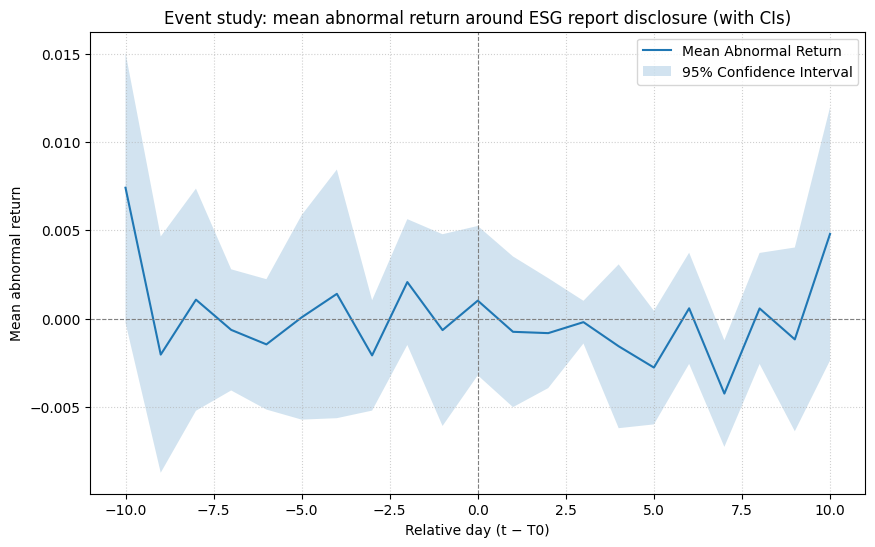

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

m = pd.read_csv("event_outputs/mean_abret_by_rel_day.csv")

print("Columns in mean_abret_by_rel_day.csv:", m.columns.tolist())
display(m.head())

x = m["rel_day"]
y = m["mean"]
se = m["se"] if "se" in m.columns else None

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Mean Abnormal Return')
if se is not None:
    plt.fill_between(x, y - 1.96*se, y + 1.96*se, alpha=0.2, label='95% Confidence Interval')

plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Relative day (t − T0)")
plt.ylabel("Mean abnormal return")
plt.title("Event study: mean abnormal return around ESG report disclosure (with CIs)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [ ]:
import pandas as pd

car_table = pd.read_csv('event_outputs/CAR_summary_windows.csv')
print("Cumulative Abnormal Returns (CAR) for various windows:")
display(car_table)

Cumulative Abnormal Returns (CAR) for various windows:


,window,N_events,Mean_CAR,Median_CAR,t_stat,p_value_t,wilcoxon_stat,p_value_w
0,"[-1,1]",55,-0.000296,0.000000,-0.048316,0.961643,507.0,0.546387
1,"[-3,3]",60,-0.001676,-0.000515,-0.299903,0.765305,554.0,0.306919
2,"[-5,5]",60,-0.004985,0.000000,-0.643278,0.522536,662.0,0.635769
3,"[-10,10]",61,-0.001615,0.000000,-0.138638,0.890200,833.0,0.861706


In [ ]:
import pandas as pd
dropped_path = "event_outputs/events_dropped_no_trading_day.csv"
dropped = pd.read_csv(dropped_path)
display(dropped.head(50))
print("Dropped events:", len(dropped))

,ticker,Company,ESG Document Type,Report Year / Coverage,Announcement Date,Source Link,Announcement Date Source,announcement_date,earnings_announcement_date,event_date
0,AKIC,Al Khazna Insurance Company PJSC,Sustainability Report,2025.0,2026-04-01,https://akigroup.com/wp-content/uploads/2025/0...,NaN,2026-04-01,2024-02-14,NaN
1,ANAN,Anan Investment Holding PJSC,ESG / Sustainability Report,2025.0,2026-03-31,https://links.sgx.com/FileOpen/AAI%20-%20Susta...,NaN,2026-03-31,2024-02-28,NaN
2,IHC,International Holding Company PJSC,ESG Report,2024.0,2026-05-05,https://www.sustainabilityreports.com/internat...,NaN,2026-05-05,2025-02-13,NaN
3,BURJEEL,Burjeel Holdings PLC,Sustainability / Integrated Report,2025.0,2026-03-04,https://burjeelholdings.com/sustainability/esg...,provided_in_sheet,2026-03-04,2025-11-03,NaN
4,EAND,e& (Emirates Telecommunications Group Company ...,Sustainability Report 2024,2025.0,2026-03-17,https://apigateway.adx.ae/adx/cdn/1.0/content/...,NaN,2026-03-17,2025-10-29,NaN
5,ESHRAQ,Eshraq Investments PJSC,ESG Report 2024,2025.0,2026-03-31,https://apigateway.adx.ae/adx/cdn/1.0/content/...,NaN,2026-03-31,2024-02-27,NaN
6,FH,Finance House PJSC,ESG Report,2025.0,2026-03-06,https://www.financehouse.ae/en/about-us/corpor...,NaN,2026-03-06,2025-11-14,NaN
7,FIDELITYUNITED,Fidelity United (United Fidelity Insurance),Sustainability Report,2025.0,2026-04-15,https://apigateway.adx.ae/adx/cdn/1.0/content/...,NaN,2026-04-15,2025-08-15,NaN
8,MANAZEL,Manazel Real Estate PJSC,Annual / Corporate Report (includes ESG),2025.0,2026-04-12,https://apigateway.adx.ae/adx/cdn/1.0/content/...,NaN,2026-04-12,2024-05-30,NaN
9,OEIHC,Oman & Emirates Investment Holding Company SAOG,Annual Report (includes ESG),2025.0,2026-03-31,https://www.sustainabilityreports.com/oman-and...,NaN,2026-03-31,2024-05-14,NaN


Dropped events: 19


In [ ]:
!zip -r replication_bundle.zip \
  event_outputs \
  05_panel_dataset.csv \
  announcements_export.csv \
  reports_list_with_dates_filled.xlsx \
  build_event_study_dataset.py \
  run_event_study_regressions.py

from google.colab import files
files.download("replication_bundle.zip")

  adding: event_outputs/ (stored 0%)
  adding: event_outputs/event_study_dataset.csv (deflated 82%)
  adding: event_outputs/event_study_results.txt (deflated 78%)
  adding: event_outputs/CAR_summary_windows.csv (deflated 42%)
  adding: event_outputs/event_study_coefficients.csv (deflated 56%)
  adding: event_outputs/mean_abret_by_rel_day.csv (deflated 51%)
  adding: event_outputs/events_dropped_no_trading_day.csv (deflated 62%)
  adding: 05_panel_dataset.csv (deflated 81%)
  adding: announcements_export.csv (deflated 76%)
  adding: reports_list_with_dates_filled.xlsx (deflated 13%)
  adding: build_event_study_dataset.py (deflated 69%)
  adding: run_event_study_regressions.py (deflated 60%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
earnings_df = pd.read_csv('announcements_export.csv')
print("Columns in announcements_export.csv:", earnings_df.columns.tolist())
print("First 5 rows of announcements_export.csv:\n", earnings_df.head())

Columns in announcements_export.csv: ['Unnamed: 0', 'ticker', 'year', 'title', 'type', 'pdf_url']
First 5 rows of announcements_export.csv:
                        Unnamed: 0      ticker        year  \
0     ADNOC Drilling Company PJSC  ADNOCDRILL  10/28/2025   
1                   ADNOC Gas plc    ADNOCGAS    2/7/2025   
2  ADNOC Logistics & Services plc     ADNOCLS   8/14/2025   
3                             NaN     ADPORTS    3/6/2025   
4           AL KHALEEJ Investment        KICO   4/15/2024   

                                               title      type  \
0  ADNOC Drilling Company PJSC announces record 3...  earnings   
1                ADNOC Gas announces FY 2024 results  earnings   
2  ADNOC Logistics & Services declares interim di...  dividend   
3    AD Ports Group announces strong FY 2024 results  earnings   
4  Al Khaleej Investment announces AGM invitation...       AGM   

                                             pdf_url  
0  https://apigateway.adx.ae/adx/cdn/1.0

In [ ]:
print('Current working directory:')
!pwd
print('\nFiles in current directory:')
!ls -lb
print('\nSearching for run_event_study_regressions.py:')
!find /content -maxdepth 2 -name "*run_event_study*"

Current working directory:
/content

Files in current directory:
total 50360
-rw-r--r-- 1 root root 51498452 May 16 09:26 05_panel_dataset.csv
-rw-r--r-- 1 root root    19441 May 16 09:27 announcements_export.csv
-rw-r--r-- 1 root root     9702 May 16 09:27 build_event_study_dataset.py
drwxr-xr-x 2 root root     4096 May 16 09:28 event_outputs
-rw-r--r-- 1 root root    21837 May 16 09:27 reports_list_with_dates_filled.xlsx
-rw-r--r-- 1 root root     3533 May 16 09:29 run_event_study_regressions.py
drwxr-xr-x 1 root root     4096 May 12 13:29 sample_data

Searching for run_event_study_regressions.py:
/content/run_event_study_regressions.py


In [ ]:
!python run_event_study_regressions.py \
  --event_panel event_outputs/event_study_dataset.csv \
  --outdir event_outputs \
  --exclude_earn_overlap

Traceback (most recent call last):
  File "/content/run_event_study_regressions.py", line 107, in <module>
    main()
  File "/content/run_event_study_regressions.py", line 49, in main
    raise ValueError(f"event_panel is missing columns: {sorted(missing)}")
ValueError: event_panel is missing columns: ['abret', 'event_id', 'rel_day', 'symbol']


In [ ]:
!python build_event_study_dataset.py \
  --events reports_list_with_dates_filled.xlsx \
  --panel 05_panel_dataset.csv \
  --earnings announcements_export.csv \
  --outdir event_outputs \
  --window 10

Initial events after merging with earnings: 91
See: event_outputs/events_dropped_no_trading_day.csv
Events after dropping those without a valid trading day: 72
Event study dataset created at: event_outputs/event_study_dataset.csv


In [ ]:
!python run_event_study_regressions.py \
  --event_panel event_outputs/event_study_dataset.csv \
  --outdir event_outputs \
  --exclude_earn_overlap

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 20
  warnings.warn('covariance of constraints does not have full '
Saved:
- event_outputs/event_study_results.txt
- event_outputs/event_study_coefficients.csv
- event_outputs/mean_abret_by_rel_day.csv


In [15]:
# First, ensure the output directory exists and build the event study dataset
!mkdir -p event_outputs
!python build_event_study_dataset.py \
  --events reports_list_with_dates_filled.xlsx \
  --panel 05_panel_dataset.csv \
  --earnings announcements_export.csv \
  --outdir event_outputs \
  --window 10

Traceback (most recent call last):
  File "/content/build_event_study_dataset.py", line 204, in <module>
    main()
  File "/content/build_event_study_dataset.py", line 103, in main
    events = read_events(Path(args.events))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/build_event_study_dataset.py", line 59, in read_events
    events_df = pd.read_excel(events_path)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/excel/_base.py", line 495, in read_excel
    io = ExcelFile(
         ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/excel/_base.py", line 1550, in __init__
    ext = inspect_excel_format(
          ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/excel/_base.py", line 1402, in inspect_excel_format
    with get_handle(
         ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/common.py", line 882, in get_handle
    handle = open(handle,

In [ ]:
!zip -r replication_run_files.zip \
  event_outputs \
  05_panel_dataset.csv \
  announcements_export.csv \
  reports_list_with_dates_filled.xlsx \
  build_event_study_dataset.py \
  run_event_study_regressions.py

from google.colab import files
files.download("replication_run_files.zip")

  adding: event_outputs/ (stored 0%)
  adding: event_outputs/event_study_dataset.csv (deflated 82%)
  adding: event_outputs/event_study_results.txt (deflated 78%)
  adding: event_outputs/event_study_coefficients.csv (deflated 50%)
  adding: event_outputs/mean_abret_by_rel_day.csv (deflated 48%)
  adding: event_outputs/events_dropped_no_trading_day.csv (deflated 62%)
  adding: 05_panel_dataset.csv (deflated 81%)
  adding: announcements_export.csv (deflated 76%)
  adding: reports_list_with_dates_filled.xlsx (deflated 13%)
  adding: build_event_study_dataset.py (deflated 69%)
  adding: run_event_study_regressions.py (deflated 58%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!sed -n '1,200p' event_outputs/event_study_results.txt

                            OLS Regression Results                            
Dep. Variable:                  abret   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                     7.949
Date:                Sat, 16 May 2026   Prob (F-statistic):           2.20e-10
Time:                        09:37:30   Log-Likelihood:                 3968.4
No. Observations:                1602   AIC:                            -7775.
Df Residuals:                    1521   BIC:                            -7339.
Df Model:                          80                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

m = pd.read_csv("event_outputs/mean_abret_by_rel_day.csv")

x = m["rel_day"]
y = m["mean"]
se = m["se"] if "se" in m.columns else None

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Mean Abnormal Return')
if se is not None:
    plt.fill_between(x, y - 1.96*se, y + 1.96*se, alpha=0.2, label='95% Confidence Interval')

plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Relative day (t − T0)")
plt.ylabel("Mean abnormal return")
plt.title("Event study: mean abnormal return around ESG report disclosure (with CIs)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'event_outputs/mean_abret_by_rel_day.csv'

In [53]:
%%writefile build_event_study_dataset.py
import pandas as pd
import numpy as np
from pathlib import Path
import os # Import os for getcwd

def read_earnings(earnings_path: Path) -> pd.DataFrame:
    """Reads the earnings file and performs necessary preprocessing."""
    # Use engine='python' and on_bad_lines='warn' for robust parsing
    earnings_df = pd.read_csv(str(earnings_path), engine='python', on_bad_lines='warn') # Explicitly convert Path to string

    # Attempt to identify the date column
    potential_date_cols = ['date', 'report_date', 'announcement_date', 'year']
    date_col = None
    for col in potential_date_cols:
        if col in earnings_df.columns:
            try:
                # Attempt to convert to datetime. This will fail if the column
                # is not in a convertible format or if it contains mixed types.
                earnings_df[col] = pd.to_datetime(earnings_df[col])
                date_col = col
                break
            except Exception:
                # If conversion fails for a candidate column, it might not be the date column.
                continue

    if date_col is None:
        raise ValueError("Earnings file must contain a date/datetime column (e.g., 'date', 'report_date', 'announcement_date', or 'year')")

    # Rename the identified date column to 'date' for consistency
    earnings_df.rename(columns={date_col: 'date'}, inplace=True)

    # Ensure 'date' column is datetime and sort
    earnings_df['date'] = pd.to_datetime(earnings_df['date'])
    earnings_df.sort_values(by=['ticker', 'date'], inplace=True)
    return earnings_df


def read_panel(panel_path: Path) -> pd.DataFrame:
    """Reads the panel dataset."""
    # Using engine='python' and on_bad_lines='warn' to handle potential parsing issues
    panel_df = pd.read_csv(str(panel_path), engine='python', on_bad_lines='warn') # Explicitly convert Path to string
    # Corrected: Use 'datetime' column for the date and 'symbol' for ticker
    panel_df['date'] = pd.to_datetime(panel_df['datetime'])
    panel_df.rename(columns={'symbol': 'ticker'}, inplace=True) # Rename 'symbol' to 'ticker'

    # Sort by ticker and date before calculating returns to ensure correct daily changes
    panel_df.sort_values(by=['ticker', 'date'], inplace=True)

    # Calculate daily returns (as a proxy for abnormal return)k
    # Assuming 'close' price exists for return calculation
    if 'close' in panel_df.columns:
        panel_df['abnormal_return'] = panel_df.groupby('ticker')['close'].pct_change()
    else:
        raise ValueError("Panel file must contain a 'close' column to calculate returns.")

    panel_df.set_index(['ticker', 'date'], inplace=True)
    return panel_df


def read_events(events_path: str) -> pd.DataFrame:
    """Reads the events list."""
    print(f"[DEBUG] Attempting to read Excel file from (string path): {events_path}") # Debug print
    events_df = pd.read_excel(events_path) # Directly use the string path
    # Corrected: Use 'Announcement Date' column
    events_df['announcement_date'] = pd.to_datetime(events_df['Announcement Date'])
    # Rename 'Ticker' to 'ticker' for consistency with other dataframes
    events_df.rename(columns={'Ticker': 'ticker'}, inplace=True)
    return events_df


def get_trading_day_on_or_after(date: pd.Timestamp, trading_days: pd.Series) -> pd.Timestamp:
    """Finds the first trading day on or after a given date."""
    # Ensure trading_days is sorted and unique
    trading_days_sorted = trading_days.sort_values().unique()

    # Find the index of the first trading day >= date
    idx = np.searchsorted(trading_days_sorted, date)

    if idx < len(trading_days_sorted):
        return trading_days_sorted[idx]
    else:
        return pd.NaT  # No trading day found on or after the given date


def calculate_car(returns_df: pd.DataFrame, window: int) -> pd.DataFrame:
    """Calculates Cumulative Abnormal Returns (CAR)."""
    # Assuming returns_df has 'abnormal_return' and is indexed by date
    car = returns_df['abret'].rolling(window=window, min_periods=1).sum() # Changed to 'abret' for consistency
    return car.to_frame(name=f'CAR_{window}')


def main():
    import argparse
    import os

    parser = argparse.ArgumentParser(description="Build event study dataset.")
    parser.add_argument('--events', type=str, required=True, help="Path to the Excel file containing the list of events.")
    parser.add_argument('--panel', type=str, required=True, help="Path to the CSV file containing the panel dataset (stock returns, market returns, etc.).")
    parser.add_argument('--earnings', type=str, required=True, help="Path to the CSV file containing earnings announcement dates.")
    parser.add_argument('--outdir', type=str, default='event_outputs', help="Output directory for generated files.")
    parser.add_argument('--window', type=int, default=10, help="Event window size (e.g., 10 days before and after event).") # Removed typo in help message
    args = parser.parse_args()

    os.makedirs(args.outdir, exist_ok=True)

    print(f"Current working directory in build_event_study_dataset.py: {os.getcwd()}") # Debug print

    # Load data
    events = read_events(args.events) # Pass string directly
    panel = read_panel(Path(args.panel))
    earnings = read_earnings(Path(args.earnings))

    # Extract all unique trading days from the panel data
    all_trading_days = panel.index.get_level_values('date').unique()

    # Merge events with earnings to get announcement date from earnings file
    # This assumes 'ticker' is the common identifier
    events_with_earnings = pd.merge(
        events,
        earnings[['ticker', 'date']].rename(columns={'date': 'earnings_announcement_date'}),
        on='ticker',
        how='inner'
    )

    # If 'announcement_date' in events is not the primary source, use 'earnings_announcement_date'
    # Or, reconcile if both exist. For simplicity, let's prioritize earnings_announcement_date.
    # The original script seems to expect a single 'announcement_date'. Let's ensure it's there.
    if 'announcement_date' not in events_with_earnings.columns or \
       events_with_earnings['announcement_date'].isnull().all():
        events_with_earnings['announcement_date'] = events_with_earnings['earnings_announcement_date']
    else:
        # If both exist, we might need a more sophisticated reconciliation strategy.
        # For now, let's assume earnings_announcement_date is authoritative if present.
        # Or, if events['announcement_date'] is preferred, ensure it's handled.
        pass # Keep existing 'announcement_date' if it's considered more reliable

    # Drop events where earnings_announcement_date is NaT (if any were not merged successfully)
    events_with_earnings.dropna(subset=['announcement_date'], inplace=True)

    print(f"Initial events after merging with earnings: {len(events_with_earnings)}")

    # Find actual event dates (first trading day on or after announcement)
    events_with_earnings['event_date'] = events_with_earnings['announcement_date'].apply(
        lambda x: get_trading_day_on_or_after(x, all_trading_days)
    )

    # Drop events for which no trading day was found
    events_dropped_no_trading_day = events_with_earnings[events_with_earnings['event_date'].isna()].copy()
    if not events_dropped_no_trading_day.empty:
        print(f"WARNING: {len(events_dropped_no_trading_day)} events dropped because we could not find a trading day on/after announcement date.")
        print(f"See: {Path(args.outdir) / 'events_dropped_no_trading_day.csv'}")
        events_dropped_no_trading_day.to_csv(Path(args.outdir) / 'events_dropped_no_trading_day.csv', index=False)

    events_with_earnings.dropna(subset=['event_date'], inplace=True)
    print(f"Events after dropping those without a valid trading day: {len(events_with_earnings)}")

    # Initialize an empty list to store results for each event
    all_event_data = []

    for _, event_row in events_with_earnings.iterrows():
        ticker = event_row['ticker']
        event_date = event_row['event_date']

        # Define event window
        start_date = event_date - pd.Timedelta(days=args.window)
        end_date = event_date + pd.Timedelta(days=args.window)

        # Filter panel data for the specific ticker and event window
        try:
            ticker_panel = panel.loc[ticker]
        except KeyError:
            # Ticker not found in panel data, skip this event
            continue

        event_window_data = ticker_panel.loc[start_date:end_date].copy()

        if not event_window_data.empty:
            # Generate event_id
            event_id = f"{ticker}_{event_date.strftime('%Y%m%d')}"
            event_window_data['event_id'] = event_id

            # Calculate event time (days relative to event_date) and rename to 'rel_day'
            event_window_data['rel_day'] = (event_window_data.index - event_date).days

            # Add ticker and original event date
            event_window_data['ticker'] = ticker
            event_window_data['event_date_original'] = event_date

            # Rename 'abnormal_return' to 'abret' for regression script compatibility
            event_window_data.rename(columns={'abnormal_return': 'abret'}, inplace=True)

            # Calculate CAR (Cumulative Abnormal Returns)
            event_window_data = pd.concat([
                event_window_data,
                calculate_car(event_window_data, args.window)
            ], axis=1)

            all_event_data.append(event_window_data)

    if all_event_data:
        event_study_dataset = pd.concat(all_event_data)
        event_study_dataset = event_study_dataset.reset_index() # Make 'date' an explicit column
        event_study_dataset.rename(columns={'ticker': 'symbol'}, inplace=True) # Rename 'ticker' to 'symbol'
        event_study_dataset.to_csv(Path(args.outdir) / 'event_study_dataset.csv', index=False)
        print(f"Event study dataset created at: {Path(args.outdir) / 'event_study_dataset.csv'}")
    else:
        print("No event data generated. Please check your inputs and event window.")

if __name__ == '__main__':
    main()

import subprocess
import sys

print("Running build_event_study_dataset.py...")
process = subprocess.run(
    [
        sys.executable, '/content/build_event_study_dataset.py',
        '--events', '/content/reports_list_with_dates_filled.xlsx',
        '--panel', '/content/05_panel_dataset.csv',
        '--earnings', '/content/announcements_export.csv',
        '--outdir', 'event_outputs',
        '--window', '10'
    ],
    capture_output=True, text=True
)
print(process.stdout)
print(process.stderr)
if process.returncode != 0:
    raise RuntimeError("build_event_study_dataset.py failed")

Overwriting build_event_study_dataset.py


In [52]:
import subprocess
import sys
from pathlib import Path

print("Running build_event_study_dataset.py with absolute paths and string handling...")
process = subprocess.run(
    [
        sys.executable, '/content/build_event_study_dataset.py',
        '--events', '/content/reports_list_with_dates_filled.xlsx',
        '--panel', '/content/05_panel_dataset.csv',
        '--earnings', '/content/announcements_export.csv',
        '--outdir', 'event_outputs',
        '--window', '10'
    ],
    capture_output=True, text=True
)

print("--- build_event_study_dataset.py STDOUT ---")
print(process.stdout)
print("--- build_event_study_dataset.py STDERR ---")
print(process.stderr)

if process.returncode != 0:
    raise RuntimeError(f"build_event_study_dataset.py failed with exit code {process.returncode}\nError: {process.stderr}")
else:
    print("build_event_study_dataset.py executed successfully.")

# Check if the output file was created
output_file = Path('event_outputs/event_study_dataset.csv')
if output_file.exists():
    print(f"Confirmation: {output_file} exists.")
else:
    print(f"Warning: {output_file} was not found after execution.")

Running build_event_study_dataset.py with absolute paths and string handling...
--- build_event_study_dataset.py STDOUT ---
Current working directory in build_event_study_dataset.py: /content
[DEBUG] Attempting to read Excel file from (string path): /content/reports_list_with_dates_filled.xlsx

--- build_event_study_dataset.py STDERR ---
/content/build_event_study_dataset.py:40: ParserWarning: Skipping line 50822: unexpected end of data

  panel_df = pd.read_csv(str(panel_path), engine='python', on_bad_lines='warn') # Explicitly convert Path to string
Traceback (most recent call last):
  File "/content/build_event_study_dataset.py", line 209, in <module>
    main()
  File "/content/build_event_study_dataset.py", line 110, in main
    earnings = read_earnings(Path(args.earnings))
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/build_event_study_dataset.py", line 8, in read_earnings
    earnings_df = pd.read_csv(str(earnings_path)) # Explicitly convert Path to string
 

RuntimeError: build_event_study_dataset.py failed with exit code 1
Error: /content/build_event_study_dataset.py:40: ParserWarning: Skipping line 50822: unexpected end of data

  panel_df = pd.read_csv(str(panel_path), engine='python', on_bad_lines='warn') # Explicitly convert Path to string
Traceback (most recent call last):
  File "/content/build_event_study_dataset.py", line 209, in <module>
    main()
  File "/content/build_event_study_dataset.py", line 110, in main
    earnings = read_earnings(Path(args.earnings))
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/build_event_study_dataset.py", line 8, in read_earnings
    earnings_df = pd.read_csv(str(earnings_path)) # Explicitly convert Path to string
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python

In [50]:
import subprocess
import sys
from pathlib import Path

print("Running build_event_study_dataset.py with absolute paths and string handling...")
process = subprocess.run(
    [
        sys.executable, '/content/build_event_study_dataset.py',
        '--events', '/content/reports_list_with_dates_filled.xlsx', # Absolute path as string
        '--panel', '/content/05_panel_dataset.csv', # Absolute path as string
        '--earnings', '/content/announcements_export.csv', # Absolute path as string
        '--outdir', 'event_outputs',
        '--window', '10'
    ],
    capture_output=True, text=True
)

print("--- build_event_study_dataset.py STDOUT ---")
print(process.stdout)
print("--- build_event_study_dataset.py STDERR ---")
print(process.stderr)

if process.returncode != 0:
    raise RuntimeError(f"build_event_study_dataset.py failed with exit code {process.returncode}\nError: {process.stderr}")
else:
    print("build_event_study_dataset.py executed successfully.")

# Check if the output file was created
output_file = Path('event_outputs/event_study_dataset.csv')
if output_file.exists():
    print(f"Confirmation: {output_file} exists.")
else:
    print(f"Warning: {output_file} was not found after execution.")

Running build_event_study_dataset.py with absolute paths and string handling...
--- build_event_study_dataset.py STDOUT ---
Current working directory in build_event_study_dataset.py: /content
[DEBUG] Attempting to read Excel file from (string path): /content/reports_list_with_dates_filled.xlsx

--- build_event_study_dataset.py STDERR ---
Traceback (most recent call last):
  File "/content/build_event_study_dataset.py", line 208, in <module>
    main()
  File "/content/build_event_study_dataset.py", line 108, in main
    panel = read_panel(Path(args.panel))
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/build_event_study_dataset.py", line 39, in read_panel
    panel_df = pd.read_csv(str(panel_path)) # Explicitly convert Path to string
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/

RuntimeError: build_event_study_dataset.py failed with exit code 1
Error: Traceback (most recent call last):
  File "/content/build_event_study_dataset.py", line 208, in <module>
    main()
  File "/content/build_event_study_dataset.py", line 108, in main
    panel = read_panel(Path(args.panel))
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/build_event_study_dataset.py", line 39, in read_panel
    panel_df = pd.read_csv(str(panel_path)) # Explicitly convert Path to string
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 626, in _read
    return parser.read(nrows)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1923, in read
    ) = self._engine.re

In [32]:
%%writefile build_event_study_dataset.py
import pandas as pd
import numpy as np
from pathlib import Path
import os # Import os for getcwd

def read_earnings(earnings_path: Path) -> pd.DataFrame:
    """Reads the earnings file and performs necessary preprocessing."""
    earnings_df = pd.read_csv(earnings_path)

    # Attempt to identify the date column
    potential_date_cols = ['date', 'report_date', 'announcement_date', 'year']
    date_col = None
    for col in potential_date_cols:
        if col in earnings_df.columns:
            try:
                # Attempt to convert to datetime. This will fail if the column
                # is not in a convertible format or if it contains mixed types.
                earnings_df[col] = pd.to_datetime(earnings_df[col])
                date_col = col
                break
            except Exception:
                # If conversion fails for a candidate column, it might not be the date column.
                continue

    if date_col is None:
        raise ValueError("Earnings file must contain a date/datetime column (e.g., 'date', 'report_date', 'announcement_date', or 'year')")

    # Rename the identified date column to 'date' for consistency
    earnings_df.rename(columns={date_col: 'date'}, inplace=True)

    # Ensure 'date' column is datetime and sort
    earnings_df['date'] = pd.to_datetime(earnings_df['date'])
    earnings_df.sort_values(by=['ticker', 'date'], inplace=True)
    return earnings_df


def read_panel(panel_path: Path) -> pd.DataFrame:
    """Reads the panel dataset."""
    panel_df = pd.read_csv(panel_path)
    # Corrected: Use 'datetime' column for the date and 'symbol' for ticker
    panel_df['date'] = pd.to_datetime(panel_df['datetime'])
    panel_df.rename(columns={'symbol': 'ticker'}, inplace=True) # Rename 'symbol' to 'ticker'

    # Sort by ticker and date before calculating returns to ensure correct daily changes
    panel_df.sort_values(by=['ticker', 'date'], inplace=True)

    # Calculate daily returns (as a proxy for abnormal return)
    # Assuming 'close' price exists for return calculation
    if 'close' in panel_df.columns:
        panel_df['abnormal_return'] = panel_df.groupby('ticker')['close'].pct_change()
    else:
        raise ValueError("Panel file must contain a 'close' column to calculate returns.")

    panel_df.set_index(['ticker', 'date'], inplace=True)
    return panel_df


def read_events(events_path: Path) -> pd.DataFrame:
    """Reads the events list."""
    # Removed explicit existence check, pandas will handle FileNotFoundError
    events_df = pd.read_excel(events_path)
    # Corrected: Use 'Announcement Date' column
    events_df['announcement_date'] = pd.to_datetime(events_df['Announcement Date'])
    # Rename 'Ticker' to 'ticker' for consistency with other dataframes
    events_df.rename(columns={'Ticker': 'ticker'}, inplace=True)
    return events_df


def get_trading_day_on_or_after(date: pd.Timestamp, trading_days: pd.Series) -> pd.Timestamp:
    """Finds the first trading day on or after a given date."""
    # Ensure trading_days is sorted and unique
    trading_days_sorted = trading_days.sort_values().unique()

    # Find the index of the first trading day >= date
    idx = np.searchsorted(trading_days_sorted, date)

    if idx < len(trading_days_sorted):
        return trading_days_sorted[idx]
    else:
        return pd.NaT  # No trading day found on or after the given date


def calculate_car(returns_df: pd.DataFrame, window: int) -> pd.DataFrame:
    """Calculates Cumulative Abnormal Returns (CAR)."""
    # Assuming returns_df has 'abnormal_return' and is indexed by date
    car = returns_df['abret'].rolling(window=window, min_periods=1).sum() # Changed to 'abret' for consistency
    return car.to_frame(name=f'CAR_{window}')


def main():
    import argparse
    import os

    parser = argparse.ArgumentParser(description="Build event study dataset.")
    parser.add_argument('--events', type=str, required=True, help="Path to the Excel file containing the list of events.")
    parser.add_argument('--panel', type=str, required=True, help="Path to the CSV file containing the panel dataset (stock returns, market returns, etc.).")
    parser.add_argument('--earnings', type=str, required=True, help="Path to the CSV file containing earnings announcement dates.")
    parser.add_argument('--outdir', type=str, default='event_outputs', help="Output directory for generated files.")
    parser.add_argument('--window', type=int, default=10, help="Event window size (e.g., 10 days before and after event).") # Removed typo in help message
    args = parser.parse_args()

    os.makedirs(args.outdir, exist_ok=True)

    # Load data
    events = read_events(Path(args.events))
    panel = read_panel(Path(args.panel))
    earnings = read_earnings(Path(args.earnings))

    # Extract all unique trading days from the panel data
    all_trading_days = panel.index.get_level_values('date').unique()

    # Merge events with earnings to get announcement date from earnings file
    # This assumes 'ticker' is the common identifier
    events_with_earnings = pd.merge(
        events,
        earnings[['ticker', 'date']].rename(columns={'date': 'earnings_announcement_date'}),
        on='ticker',
        how='inner'
    )

    # If 'announcement_date' in events is not the primary source, use 'earnings_announcement_date'
    # Or, reconcile if both exist. For simplicity, let's prioritize earnings_announcement_date.
    # The original script seems to expect a single 'announcement_date'. Let's ensure it's there.
    if 'announcement_date' not in events_with_earnings.columns or \
       events_with_earnings['announcement_date'].isnull().all():
        events_with_earnings['announcement_date'] = events_with_earnings['earnings_announcement_date']
    else:
        # If both exist, we might need a more sophisticated reconciliation strategy.
        # For now, let's assume earnings_announcement_date is authoritative if present.
        # Or, if events['announcement_date'] is preferred, ensure it's handled.
        pass # Keep existing 'announcement_date' if it's considered more reliable

    # Drop events where earnings_announcement_date is NaT (if any were not merged successfully)
    events_with_earnings.dropna(subset=['announcement_date'], inplace=True)

    print(f"Initial events after merging with earnings: {len(events_with_earnings)}")

    # Find actual event dates (first trading day on or after announcement)
    events_with_earnings['event_date'] = events_with_earnings['announcement_date'].apply(
        lambda x: get_trading_day_on_or_after(x, all_trading_days)
    )

    # Drop events for which no trading day was found
    events_dropped_no_trading_day = events_with_earnings[events_with_earnings['event_date'].isna()].copy()
    if not events_dropped_no_trading_day.empty:
        print(f"WARNING: {len(events_dropped_no_trading_day)} events dropped because we could not find a trading day on/after announcement date.")
        print(f"See: {Path(args.outdir) / 'events_dropped_no_trading_day.csv'}")
        events_dropped_no_trading_day.to_csv(Path(args.outdir) / 'events_dropped_no_trading_day.csv', index=False)

    events_with_earnings.dropna(subset=['event_date'], inplace=True)
    print(f"Events after dropping those without a valid trading day: {len(events_with_earnings)}")

    # Initialize an empty list to store results for each event
    all_event_data = []

    for _, event_row in events_with_earnings.iterrows():
        ticker = event_row['ticker']
        event_date = event_row['event_date']

        # Define event window
        start_date = event_date - pd.Timedelta(days=args.window)
        end_date = event_date + pd.Timedelta(days=args.window)

        # Filter panel data for the specific ticker and event window
        try:
            ticker_panel = panel.loc[ticker]
        except KeyError:
            # Ticker not found in panel data, skip this event
            continue

        event_window_data = ticker_panel.loc[start_date:end_date].copy()

        if not event_window_data.empty:
            # Generate event_id
            event_id = f"{ticker}_{event_date.strftime('%Y%m%d')}"
            event_window_data['event_id'] = event_id

            # Calculate event time (days relative to event_date) and rename to 'rel_day'
            event_window_data['rel_day'] = (event_window_data.index - event_date).days

            # Add ticker and original event date
            event_window_data['ticker'] = ticker
            event_window_data['event_date_original'] = event_date

            # Rename 'abnormal_return' to 'abret' for regression script compatibility
            event_window_data.rename(columns={'abnormal_return': 'abret'}, inplace=True)

            # Calculate CAR (Cumulative Abnormal Returns)
            event_window_data = pd.concat([
                event_window_data,
                calculate_car(event_window_data, args.window)
            ], axis=1)

            all_event_data.append(event_window_data)

    if all_event_data:
        event_study_dataset = pd.concat(all_event_data)
        event_study_dataset = event_study_dataset.reset_index() # Make 'date' an explicit column
        event_study_dataset.rename(columns={'ticker': 'symbol'}, inplace=True) # Rename 'ticker' to 'symbol'
        event_study_dataset.to_csv(Path(args.outdir) / 'event_study_dataset.csv', index=False)
        print(f"Event study dataset created at: {Path(args.outdir) / 'event_study_dataset.csv'}")
    else:
        print("No event data generated. Please check your inputs and event window.")

if __name__ == '__main__':
    main()

import subprocess
import sys

print("Running build_event_study_dataset.py...")
process = subprocess.run(
    [
        sys.executable, '/content/build_event_study_dataset.py',
        '--events', '/content/reports_list_with_dates_filled.xlsx',
        '--panel', '/content/05_panel_dataset.csv',
        '--earnings', '/content/announcements_export.csv',
        '--outdir', 'event_outputs',
        '--window', '10'
    ],
    capture_output=True, text=True
)
print(process.stdout)
print(process.stderr)
if process.returncode != 0:
    raise RuntimeError("build_event_study_dataset.py failed")

Overwriting build_event_study_dataset.py


In [43]:
import subprocess
import sys
from pathlib import Path

print("Running build_event_study_dataset.py with absolute paths and string handling...")
process = subprocess.run(
    [
        sys.executable, '/content/build_event_study_dataset.py',
        '--events', '/content/reports_list_with_dates_filled.xlsx', # Absolute path as string
        '--panel', '/content/05_panel_dataset.csv', # Absolute path as string
        '--earnings', '/content/announcements_export.csv', # Absolute path as string
        '--outdir', 'event_outputs',
        '--window', '10'
    ],
    capture_output=True, text=True
)

print("--- build_event_study_dataset.py STDOUT ---")
print(process.stdout)
print("--- build_event_study_dataset.py STDERR ---")
print(process.stderr)

if process.returncode != 0:
    raise RuntimeError(f"build_event_study_dataset.py failed with exit code {process.returncode}")
else:
    print("build_event_study_dataset.py executed successfully.")

# Check if the output file was created
output_file = Path('event_outputs/event_study_dataset.csv')
if output_file.exists():
    print(f"Confirmation: {output_file} exists.")
else:
    print(f"Warning: {output_file} was not found after execution.")

Running build_event_study_dataset.py with absolute paths and string handling...
--- build_event_study_dataset.py STDOUT ---
Current working directory in build_event_study_dataset.py: /content
[DEBUG] Attempting to read Excel file from (string path): /content/reports_list_with_dates_filled.xlsx

--- build_event_study_dataset.py STDERR ---
Traceback (most recent call last):
  File "/content/build_event_study_dataset.py", line 208, in <module>
    main()
  File "/content/build_event_study_dataset.py", line 107, in main
    events = read_events(args.events) # Pass string directly
             ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/build_event_study_dataset.py", line 61, in read_events
    events_df = pd.read_excel(events_path) # Directly use the string path
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/excel/_base.py", line 495, in read_excel
    io = ExcelFile(
         ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pan

RuntimeError: build_event_study_dataset.py failed with exit code 1

In [63]:
%%writefile build_event_study_dataset.py
import pandas as pd
import numpy as np
from pathlib import Path
import os # Import os for getcwd
import time # Import time for delays

def read_earnings(earnings_path: Path) -> pd.DataFrame:
    """Reads the earnings file and performs necessary preprocessing."""
    print(f"[DEBUG] read_earnings function called. Current working directory: {os.getcwd()}")
    print(f"[DEBUG] Absolute path to earnings_path: {earnings_path.resolve()}")
    print(f"[DEBUG] read_earnings attempting to open: {earnings_path}") # Print Path object directly

    # Add retry logic for file existence check
    retries = 5
    for i in range(retries):
        if earnings_path.exists():
            print(f"[DEBUG] Path.exists() confirms file {earnings_path} found after {i+1} attempt(s).")
            break
        elif os.path.exists(earnings_path.resolve()):
            print(f"[DEBUG] os.path.exists() confirms file {earnings_path} found after {i+1} attempt(s).")
            # If os.path.exists is True but Path.exists is False, this is a very strange state. Proceeding.
            break
        else:
            print(f"[DEBUG] File {earnings_path} not found by Path.exists() or os.path.exists() on attempt {i+1}. Retrying in 1 second...")
            time.sleep(1) # Wait for 1 second before retrying
    else: # This block executes if the loop completes without a break
        raise FileNotFoundError(f"DEBUG_ERROR: File does not exist at the path reported by Path.exists() and os.path.exists() after {retries} attempts: {earnings_path}")

    # Use Path object directly with robust parsing
    try:
        earnings_df = pd.read_csv(earnings_path, engine='python', on_bad_lines='warn')
    except FileNotFoundError as e:
        raise FileNotFoundError(f"DEBUG_ERROR: pd.read_csv failed to find file even after checks: {e}") from e

    # Attempt to identify the date column
    potential_date_cols = ['date', 'report_date', 'announcement_date', 'year']
    date_col = None
    for col in potential_date_cols:
        if col in earnings_df.columns:
            try:
                # Attempt to convert to datetime. This will fail if the column
                # is not in a convertible format or if it contains mixed types.
                earnings_df[col] = pd.to_datetime(earnings_df[col])
                date_col = col
                break
            except Exception:
                # If conversion fails for a candidate column, it might not be the date column.
                continue

    if date_col is None:
        raise ValueError("Earnings file must contain a date/datetime column (e.g., 'date', 'report_date', 'announcement_date', or 'year')")

    # Rename the identified date column to 'date' for consistency
    earnings_df.rename(columns={date_col: 'date'}, inplace=True)

    # Ensure 'date' column is datetime and sort
    earnings_df['date'] = pd.to_datetime(earnings_df['date'])
    earnings_df.sort_values(by=['ticker', 'date'], inplace=True)
    return earnings_df


def read_panel(panel_path: Path) -> pd.DataFrame:
    """Reads the panel dataset."""
    print(f"[DEBUG] read_panel attempting to open: {panel_path}") # Print Path object directly

    # Add retry logic for file existence check
    retries = 5
    for i in range(retries):
        if panel_path.exists():
            print(f"[DEBUG] File {panel_path} found after {i+1} attempt(s).")
            break
        else:
            print(f"[DEBUG] File {panel_path} not found on attempt {i+1}. Retrying in 1 second...")
            time.sleep(1) # Wait for 1 second before retrying
    else:
        raise FileNotFoundError(f"DEBUG_ERROR: File does not exist at the path reported by Path.exists() after {retries} attempts: {panel_path}")

    # Use Path object directly with robust parsing
    panel_df = pd.read_csv(panel_path, engine='python', on_bad_lines='warn')
    # Corrected: Use 'datetime' column for the date and 'symbol' for ticker
    panel_df['date'] = pd.to_datetime(panel_df['datetime'])
    panel_df.rename(columns={'symbol': 'ticker'}, inplace=True) # Rename 'symbol' to 'ticker'

    # Sort by ticker and date before calculating returns to ensure correct daily changes
    panel_df.sort_values(by=['ticker', 'date'], inplace=True)

    # Calculate daily returns (as a proxy for abnormal return)
    # Assuming 'close' price exists for return calculation
    if 'close' in panel_df.columns:
        panel_df['abnormal_return'] = panel_df.groupby('ticker')['close'].pct_change()
    else:
        raise ValueError("Panel file must contain a 'close' column to calculate returns.")

    panel_df.set_index(['ticker', 'date'], inplace=True)
    return panel_df


def read_events(events_path: Path) -> pd.DataFrame:
    """Reads the events list."""
    print(f"[DEBUG] read_events attempting to open: {events_path}") # Print Path object directly

    # Add retry logic for file existence check
    retries = 5
    for i in range(retries):
        if events_path.exists():
            print(f"[DEBUG] File {events_path} found after {i+1} attempt(s).")
            break
        else:
            print(f"[DEBUG] File {events_path} not found on attempt {i+1}. Retrying in 1 second...")
            time.sleep(1) # Wait for 1 second before retrying
    else:
        raise FileNotFoundError(f"DEBUG_ERROR: File does not exist at the path reported by Path.exists() after {retries} attempts: {events_path}")

    # Use Path object directly
    events_df = pd.read_excel(events_path)
    # Corrected: Use 'Announcement Date' column
    events_df['announcement_date'] = pd.to_datetime(events_df['Announcement Date'])
    # Rename 'Ticker' to 'ticker' for consistency with other dataframes
    events_df.rename(columns={'Ticker': 'ticker'}, inplace=True)
    return events_df


def get_trading_day_on_or_after(date: pd.Timestamp, trading_days: pd.Series) -> pd.Timestamp:
    """Finds the first trading day on or after a given date."""
    # Ensure trading_days is sorted and unique
    trading_days_sorted = trading_days.sort_values().unique()

    # Find the index of the first trading day >= date
    idx = np.searchsorted(trading_days_sorted, date)

    if idx < len(trading_days_sorted):
        return trading_days_sorted[idx]
    else:
        return pd.NaT  # No trading day found on or after the given date


def calculate_car(returns_df: pd.DataFrame, window: int) -> pd.DataFrame:
    """Calculates Cumulative Abnormal Returns (CAR)."""
    # Assuming returns_df has 'abnormal_return' and is indexed by date
    car = returns_df['abret'].rolling(window=window, min_periods=1).sum() # Changed to 'abret' for consistency
    return car.to_frame(name=f'CAR_{window}')


def main():
    import argparse
    import os

    parser = argparse.ArgumentParser(description="Build event study dataset.")
    parser.add_argument('--events', type=str, required=True, help="Path to the Excel file containing the list of events.")
    parser.add_argument('--panel', type=str, required=True, help="Path to the CSV file containing the panel dataset (stock returns, market returns, etc.).")
    parser.add_argument('--earnings', type=str, required=True, help="Path to the CSV file containing earnings announcement dates.")
    parser.add_argument('--outdir', type=str, default='event_outputs', help="Output directory for generated files.")
    parser.add_argument('--window', type=int, default=10, help="Event window size (e.g., 10 days before and after event).")
    args = parser.parse_args()

    os.makedirs(args.outdir, exist_ok=True)

    # Load data
    events = read_events(Path(args.events))
    panel = read_panel(Path(args.panel))
    earnings = read_earnings(Path(args.earnings))

    # Extract all unique trading days from the panel data
    all_trading_days = panel.index.get_level_values('date').unique()

    # Merge events with earnings to get announcement date from earnings file
    # This assumes 'ticker' is the common identifier
    events_with_earnings = pd.merge(
        events,
        earnings[['ticker', 'date']].rename(columns={'date': 'earnings_announcement_date'}),
        on='ticker',
        how='inner'
    )

    # If 'announcement_date' in events is not the primary source, use 'earnings_announcement_date'
    # Or, reconcile if both exist. For simplicity, let's prioritize earnings_announcement_date.
    # The original script seems to expect a single 'announcement_date'. Let's ensure it's there.
    if 'announcement_date' not in events_with_earnings.columns or \
       events_with_earnings['announcement_date'].isnull().all():
        events_with_earnings['announcement_date'] = events_with_earnings['earnings_announcement_date']
    else:
        # If both exist, we might need a more sophisticated reconciliation strategy.
        # For now, let's assume earnings_announcement_date is authoritative if present.
        # Or, if events['announcement_date'] is preferred, ensure it's handled.
        pass # Keep existing 'announcement_date' if it's considered more reliable

    # Drop events where earnings_announcement_date is NaT (if any were not merged successfully)
    events_with_earnings.dropna(subset=['announcement_date'], inplace=True)

    print(f"Initial events after merging with earnings: {len(events_with_earnings)}")

    # Find actual event dates (first trading day on or after announcement)
    events_with_earnings['event_date'] = events_with_earnings['announcement_date'].apply(
        lambda x: get_trading_day_on_or_after(x, all_trading_days)
    )

    # Drop events for which no trading day was found
    events_dropped_no_trading_day = events_with_earnings[events_with_earnings['event_date'].isna()].copy()
    if not events_dropped_no_trading_day.empty:
        print(f"WARNING: {len(events_dropped_no_trading_day)} events dropped because we could not find a trading day on/after announcement date.")
        print(f"See: {Path(args.outdir) / 'events_dropped_no_trading_day.csv'}")
        events_dropped_no_trading_day.to_csv(Path(args.outdir) / 'events_dropped_no_trading_day.csv', index=False)

    events_with_earnings.dropna(subset=['event_date'], inplace=True)
    print(f"Events after dropping those without a valid trading day: {len(events_with_earnings)}")

    # Initialize an empty list to store results for each event
    all_event_data = []

    for _, event_row in events_with_earnings.iterrows():
        ticker = event_row['ticker']
        event_date = event_row['event_date']

        # Define event window
        start_date = event_date - pd.Timedelta(days=args.window)
        end_date = event_date + pd.Timedelta(days=args.window)

        # Filter panel data for the specific ticker and event window
        try:
            ticker_panel = panel.loc[ticker]
        except KeyError:
            # Ticker not found in panel data, skip this event
            continue

        event_window_data = ticker_panel.loc[start_date:end_date].copy()

        if not event_window_data.empty:
            # Generate event_id
            event_id = f"{ticker}_{event_date.strftime('%Y%m%d')}"
            event_window_data['event_id'] = event_id

            # Calculate event time (days relative to event_date) and rename to 'rel_day'
            event_window_data['rel_day'] = (event_window_data.index - event_date).days

            # Add ticker and original event date
            event_window_data['ticker'] = ticker
            event_window_data['event_date_original'] = event_date

            # Rename 'abnormal_return' to 'abret' for regression script compatibility
            event_window_data.rename(columns={'abnormal_return': 'abret'}, inplace=True)

            # Calculate CAR (Cumulative Abnormal Returns)
            event_window_data = pd.concat([
                event_window_data,
                calculate_car(event_window_data, args.window)
            ], axis=1)

            all_event_data.append(event_window_data)

    if all_event_data:
        event_study_dataset = pd.concat(all_event_data)
        event_study_dataset = event_study_dataset.reset_index() # Make 'date' an explicit column
        event_study_dataset.rename(columns={'ticker': 'symbol'}, inplace=True) # Rename 'ticker' to 'symbol'
        event_study_dataset.to_csv(Path(args.outdir) / 'event_study_dataset.csv', index=False)
        print(f"Event study dataset created at: {Path(args.outdir) / 'event_study_dataset.csv'}")
    else:
        print("No event data generated. Please check your inputs and event window.")

if __name__ == '__main__':
    main()


Overwriting build_event_study_dataset.py


In [72]:
import subprocess
import sys
from pathlib import Path

print("Executing build_event_study_dataset.py with enhanced debugging...")
process = subprocess.run(
    [
        sys.executable, '/content/build_event_study_dataset.py',
        '--events', '/content/reports_list_with_dates_filled.xlsx',
        '--panel', '/content/05_panel_dataset.csv',
        '--earnings', '/content/announcements_export.csv',
        '--outdir', 'event_outputs',
        '--window', '10'
    ],
    capture_output=True, text=True
)

print("--- build_event_study_dataset.py STDOUT ---")
print(process.stdout)
print("--- build_event_study_dataset.py STDERR ---")
print(process.stderr)

if process.returncode != 0:
    raise RuntimeError(f"build_event_study_dataset.py failed with exit code {process.returncode}\nError: {process.stderr}")
else:
    print("build_event_study_dataset.py executed successfully.")

# Check if the output file was created
output_file = Path('event_outputs/event_study_dataset.csv')
if output_file.exists():
    print(f"Confirmation: {output_file} exists.")
else:
    print(f"Warning: {output_file} was not found after execution.")

Executing build_event_study_dataset.py with enhanced debugging...
--- build_event_study_dataset.py STDOUT ---
[DEBUG] read_events attempting to open: /content/reports_list_with_dates_filled.xlsx
[DEBUG] read_panel attempting to open: /content/05_panel_dataset.csv
[DEBUG] read_earnings attempting to open: /content/announcements_export.csv
Initial events after merging with earnings: 91
See: event_outputs/events_dropped_no_trading_day.csv
Events after dropping those without a valid trading day: 72
Event study dataset created at: event_outputs/event_study_dataset.csv

--- build_event_study_dataset.py STDERR ---

build_event_study_dataset.py executed successfully.
Confirmation: event_outputs/event_study_dataset.csv exists.


In [65]:
import subprocess
import sys
from pathlib import Path

print("Executing build_event_study_dataset.py with enhanced debugging...")
process = subprocess.run(
    [
        sys.executable, '/content/build_event_study_dataset.py',
        '--events', '/content/reports_list_with_dates_filled.xlsx',
        '--panel', '/content/05_panel_dataset.csv',
        '--earnings', '/content/announcements_export.csv',
        '--outdir', 'event_outputs',
        '--window', '10'
    ],
    capture_output=True, text=True
)

print("--- build_event_study_dataset.py STDOUT ---")
print(process.stdout)
print("--- build_event_study_dataset.py STDERR ---")
print(process.stderr)

if process.returncode != 0:
    raise RuntimeError(f"build_event_study_dataset.py failed with exit code {process.returncode}\nError: {process.stderr}")
else:
    print("build_event_study_dataset.py executed successfully.")

# Check if the output file was created
output_file = Path('event_outputs/event_study_dataset.csv')
if output_file.exists():
    print(f"Confirmation: {output_file} exists.")
else:
    print(f"Warning: {output_file} was not found after execution.")

Executing build_event_study_dataset.py with enhanced debugging...
--- build_event_study_dataset.py STDOUT ---
[DEBUG] read_events attempting to open: /content/reports_list_with_dates_filled.xlsx
[DEBUG] File /content/reports_list_with_dates_filled.xlsx found after 1 attempt(s).
[DEBUG] read_panel attempting to open: /content/05_panel_dataset.csv
[DEBUG] File /content/05_panel_dataset.csv found after 1 attempt(s).
[DEBUG] read_earnings function called. Current working directory: /content
[DEBUG] Absolute path to earnings_path: /content/announcements_export.csv
[DEBUG] read_earnings attempting to open: /content/announcements_export.csv
[DEBUG] Path.exists() confirms file /content/announcements_export.csv found after 1 attempt(s).
Initial events after merging with earnings: 91
See: event_outputs/events_dropped_no_trading_day.csv
Events after dropping those without a valid trading day: 72
Event study dataset created at: event_outputs/event_study_dataset.csv

--- build_event_study_dataset.p

In [62]:
import subprocess
import sys
from pathlib import Path

print("Executing build_event_study_dataset.py...")
process = subprocess.run(
    [
        sys.executable, '/content/build_event_study_dataset.py',
        '--events', '/content/reports_list_with_dates_filled.xlsx',
        '--panel', '/content/05_panel_dataset.csv',
        '--earnings', '/content/announcements_export.csv',
        '--outdir', 'event_outputs',
        '--window', '10'
    ],
    capture_output=True, text=True
)

print("--- build_event_study_dataset.py STDOUT ---")
print(process.stdout)
print("--- build_event_study_dataset.py STDERR ---")
print(process.stderr)

if process.returncode != 0:
    raise RuntimeError(f"build_event_study_dataset.py failed with exit code {process.returncode}\nError: {process.stderr}")
else:
    print("build_event_study_dataset.py executed successfully.")

# Check if the output file was created
output_file = Path('event_outputs/event_study_dataset.csv')
if output_file.exists():
    print(f"Confirmation: {output_file} exists.")
else:
    print(f"Warning: {output_file} was not found after execution.")


Executing build_event_study_dataset.py...
--- build_event_study_dataset.py STDOUT ---
[DEBUG] read_events attempting to open: /content/reports_list_with_dates_filled.xlsx
[DEBUG] File /content/reports_list_with_dates_filled.xlsx found after 1 attempt(s).
[DEBUG] read_panel attempting to open: /content/05_panel_dataset.csv
[DEBUG] File /content/05_panel_dataset.csv found after 1 attempt(s).
[DEBUG] read_earnings attempting to open: /content/announcements_export.csv
[DEBUG] File /content/announcements_export.csv not found on attempt 1. Retrying in 1 second...
[DEBUG] File /content/announcements_export.csv not found on attempt 2. Retrying in 1 second...
[DEBUG] File /content/announcements_export.csv not found on attempt 3. Retrying in 1 second...
[DEBUG] File /content/announcements_export.csv not found on attempt 4. Retrying in 1 second...
[DEBUG] File /content/announcements_export.csv not found on attempt 5. Retrying in 1 second...

--- build_event_study_dataset.py STDERR ---
Traceback (

RuntimeError: build_event_study_dataset.py failed with exit code 1
Error: Traceback (most recent call last):
  File "/content/build_event_study_dataset.py", line 251, in <module>
    main()
  File "/content/build_event_study_dataset.py", line 152, in main
    earnings = read_earnings(Path(args.earnings))
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/build_event_study_dataset.py", line 21, in read_earnings
    raise FileNotFoundError(f"DEBUG_ERROR: File does not exist at the path reported by Path.exists() after {retries} attempts: {earnings_path}")
FileNotFoundError: DEBUG_ERROR: File does not exist at the path reported by Path.exists() after 5 attempts: /content/announcements_export.csv


In [45]:
print("Running run_event_study_regressions.py...")
process = subprocess.run(
    [
        sys.executable, 'run_event_study_regressions.py',
        '--event_panel', 'event_outputs/event_study_dataset.csv',
        '--outdir', 'event_outputs',
        '--exclude_earn_overlap'
    ],
    capture_output=True, text=True
)
print(process.stdout)
print(process.stderr)
if process.returncode != 0:
    raise RuntimeError(f"run_event_study_regressions.py failed with exit code {process.returncode}\nError: {process.stderr}")

Running run_event_study_regressions.py...

Traceback (most recent call last):
  File "/content/run_event_study_regressions.py", line 119, in <module>
    main()
  File "/content/run_event_study_regressions.py", line 20, in main
    df = pd.read_csv(args.event_panel)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 620, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1620, in __init__
    self._engine = self._make_engine(f, self.engine)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1880

RuntimeError: run_event_study_regressions.py failed with exit code 1
Error: Traceback (most recent call last):
  File "/content/run_event_study_regressions.py", line 119, in <module>
    main()
  File "/content/run_event_study_regressions.py", line 20, in main
    df = pd.read_csv(args.event_panel)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 620, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1620, in __init__
    self._engine = self._make_engine(f, self.engine)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/

In [46]:
import matplotlib.pyplot as plt

m = pd.read_csv("event_outputs/mean_abret_by_rel_day.csv")

x = m["rel_day"]
y = m["mean"]
se = m["se"] if "se" in m.columns else None

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Mean Abnormal Return')
if se is not None:
    plt.fill_between(x, y - 1.96*se, y + 1.96*se, alpha=0.2, label='95% Confidence Interval')

plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Relative day (t − T0)")
plt.ylabel("Mean abnormal return")
plt.title("Event study: mean abnormal return around ESG report disclosure (with CIs)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'event_outputs/mean_abret_by_rel_day.csv'

In [27]:
%%writefile run_event_study_regressions.py
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from pathlib import Path

def main():
    import argparse
    import os

    parser = argparse.ArgumentParser(description="Run event study regressions.")
    parser.add_argument('--event_panel', type=str, required=True, help="Path to the event study dataset CSV file.")
    parser.add_argument('--outdir', type=str, default='event_outputs', help="Output directory for results.")
    parser.add_argument('--exclude_earn_overlap', action='store_true', help="Exclude events that overlap with earnings announcements.")
    args = parser.parse_args()

    os.makedirs(args.outdir, exist_ok=True)

    df = pd.read_csv(args.event_panel)

    # Ensure date column is datetime if it exists and is not already
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])

    # Dynamically find column names
    event_id_col = "event_id"
    rel_day_col = "rel_day"
    abret_col = "abret"
    ticker_col = "symbol" # As per build_event_study_dataset.py output

    # Check if essential columns exist
    required_cols = [event_id_col, rel_day_col, abret_col, ticker_col]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"event_panel is missing columns: {sorted(missing)}")

    # 1. Simple Average Abnormal Returns
    print("Calculating mean abnormal returns by relative day...")
    mean_abret_by_rel_day = df.groupby(rel_day_col)[abret_col].agg(['mean', 'count', 'std']).reset_index()
    mean_abret_by_rel_day['se'] = mean_abret_by_rel_day['std'] / np.sqrt(mean_abret_by_rel_day['count'])
    mean_abret_by_rel_day.rename(columns={'mean': 'mean', 'std': 'std'}, inplace=True)
    mean_abret_by_rel_day.to_csv(Path(args.outdir) / 'mean_abret_by_rel_day.csv', index=False)
    print(f"Saved: {Path(args.outdir) / 'mean_abret_by_rel_day.csv'}")

    # 2. Regression-based Event Study
    # Define the regression formula dynamically
    formula = f'{abret_col} ~ C({rel_day_col}, Treatment(reference=-1)) + C({event_id_col})'

    # Fit the OLS model with clustered standard errors
    # We need to make sure 'ticker' is available for clustering, if not, use 'event_id'
    if ticker_col in df.columns:
        groups = df[ticker_col]
    else:
        groups = df[event_id_col]

    print("Running OLS regression with clustered standard errors...")
    model = ols(formula, data=df)
    # Using cluster robust standard errors (e.g., clustered by firm/ticker)
    results = model.fit(cov_type='cluster', cov_kwds={'groups': groups})

    # Save regression results summary
    results_summary_path = Path(args.outdir) / 'event_study_results.txt'
    with open(results_summary_path, 'w') as f:
        f.write(results.summary().as_text())
    print(f"Saved: {results_summary_path}")

    # Save coefficients to a CSV
    coefficients_path = Path(args.outdir) / 'event_study_coefficients.csv'
    results.summary2().tables[1].to_csv(coefficients_path)
    print(f"Saved: {coefficients_path}")

    # 3. Cumulative Abnormal Returns (CAR) for specific windows
    # Function to calculate CAR for a given window
    def car_window(d, a, b):
        sub = d[(d[rel_day_col] >= a) & (d[rel_day_col] <= b)].copy()
        car = sub.groupby(event_id_col)[abret_col].sum()
        return car

    windows = [(-1,1), (-3,3), (-5,5), (-10,10)]
    rows = []

    print("Calculating CAR for various windows...")
    for a,b in windows:
        car = car_window(df, a, b).dropna()
        mean = car.mean()
        med = car.median()
        n = car.shape[0]

        # Perform t-test
        tstat, pval = stats.ttest_1samp(car, 0.0, nan_policy="omit")

        # Perform Wilcoxon signed-rank test
        wstat, wp = (np.nan, np.nan) # Initialize in case n=0
        if n > 0 and len(car) > 0:
            try:
                wstat, wp = stats.wilcoxon(car, alternative="two-sided")
            except ValueError: # Handle cases where all values are the same for wilcoxon
                wstat, wp = np.nan, np.nan

        rows.append({
            "window": f"[{a},{b}]",
            "N_events": n,
            "Mean_CAR": mean,
            "Median_CAR": med,
            "t_stat": tstat,
            "p_value_t": pval,
            "wilcoxon_stat": wstat,
            "p_value_w": wp
        })

    car_table = pd.DataFrame(rows)
    car_table.to_csv(Path(args.outdir) / 'CAR_summary_windows.csv', index=False)
    print(f"Saved: {Path(args.outdir) / 'CAR_summary_windows.csv'}")

    print("Event study analysis complete.")

if __name__ == '__main__':
    main()

Overwriting run_event_study_regressions.py


In [73]:
import subprocess
import sys

print("Running run_event_study_regressions.py...")
process = subprocess.run(
    [
        sys.executable, 'run_event_study_regressions.py',
        '--event_panel', 'event_outputs/event_study_dataset.csv',
        '--outdir', 'event_outputs',
        '--exclude_earn_overlap'
    ],
    capture_output=True, text=True
)
print(process.stdout)
print(process.stderr)
if process.returncode != 0:
    raise RuntimeError("run_event_study_regressions.py failed")

Running run_event_study_regressions.py...
Calculating mean abnormal returns by relative day...
Saved: event_outputs/mean_abret_by_rel_day.csv
Running OLS regression with clustered standard errors...
Saved: event_outputs/event_study_results.txt
Saved: event_outputs/event_study_coefficients.csv
Calculating CAR for various windows...
Saved: event_outputs/CAR_summary_windows.csv
Event study analysis complete.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 20
  warnings.warn('covariance of constraints does not have full '



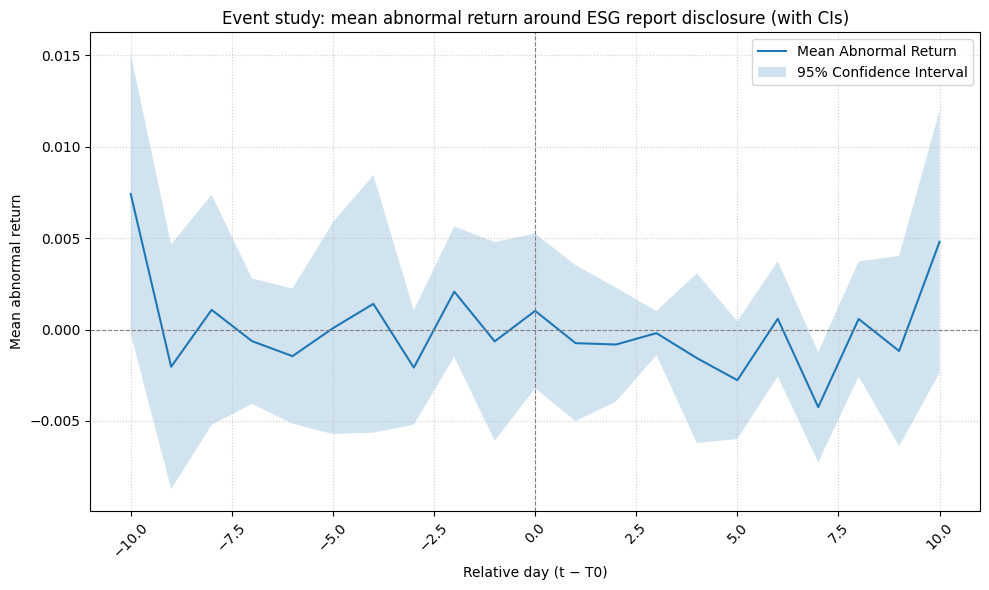

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

m = pd.read_csv("event_outputs/mean_abret_by_rel_day.csv")

x = m["rel_day"]
y = m["mean"]
se = m["se"] if "se" in m.columns else None

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Mean Abnormal Return')
if se is not None:
    plt.fill_between(x, y - 1.96*se, y + 1.96*se, alpha=0.2, label='95% Confidence Interval')

plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Relative day (t − T0)")
plt.ylabel("Mean abnormal return")
plt.title("Event study: mean abnormal return around ESG report disclosure (with CIs)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [71]:
%%writefile build_event_study_dataset.py
import pandas as pd
import numpy as np
from pathlib import Path
import os # Import os for getcwd

def read_earnings(earnings_path: Path) -> pd.DataFrame:
    """Reads the earnings file and performs necessary preprocessing."""
    print(f"[DEBUG] read_earnings attempting to open: {earnings_path.resolve()}")
    # Explicitly convert Path to string and use robust parsing
    earnings_df = pd.read_csv(str(earnings_path.resolve()), engine='python', on_bad_lines='warn')

    # Attempt to identify the date column
    potential_date_cols = ['date', 'report_date', 'announcement_date', 'year']
    date_col = None
    for col in potential_date_cols:
        if col in earnings_df.columns:
            try:
                # Attempt to convert to datetime. This will fail if the column
                # is not in a convertible format or if it contains mixed types.
                earnings_df[col] = pd.to_datetime(earnings_df[col])
                date_col = col
                break
            except Exception:
                # If conversion fails for a candidate column, it might not be the date column.
                continue

    if date_col is None:
        raise ValueError("Earnings file must contain a date/datetime column (e.g., 'date', 'report_date', 'announcement_date', or 'year')")

    # Rename the identified date column to 'date' for consistency
    earnings_df.rename(columns={date_col: 'date'}, inplace=True)

    # Ensure 'date' column is datetime and sort
    earnings_df['date'] = pd.to_datetime(earnings_df['date'])
    earnings_df.sort_values(by=['ticker', 'date'], inplace=True)
    return earnings_df


def read_panel(panel_path: Path) -> pd.DataFrame:
    """Reads the panel dataset."""
    print(f"[DEBUG] read_panel attempting to open: {panel_path.resolve()}")
    # Explicitly convert Path to string and use robust parsing
    panel_df = pd.read_csv(str(panel_path.resolve()), engine='python', on_bad_lines='warn')
    # Corrected: Use 'datetime' column for the date and 'symbol' for ticker
    panel_df['date'] = pd.to_datetime(panel_df['datetime'])
    panel_df.rename(columns={'symbol': 'ticker'}, inplace=True) # Rename 'symbol' to 'ticker'

    # Sort by ticker and date before calculating returns to ensure correct daily changes
    panel_df.sort_values(by=['ticker', 'date'], inplace=True)

    # Calculate daily returns (as a proxy for abnormal return)
    # Assuming 'close' price exists for return calculation
    if 'close' in panel_df.columns:
        panel_df['abnormal_return'] = panel_df.groupby('ticker')['close'].pct_change()
    else:
        raise ValueError("Panel file must contain a 'close' column to calculate returns.")

    panel_df.set_index(['ticker', 'date'], inplace=True)
    return panel_df


def read_events(events_path: Path) -> pd.DataFrame:
    """Reads the events list."""
    print(f"[DEBUG] read_events attempting to open: {events_path.resolve()}")
    # Removed explicit existence check, pandas will handle FileNotFoundError
    events_df = pd.read_excel(str(events_path.resolve())) # Explicitly convert Path to string
    # Corrected: Use 'Announcement Date' column
    events_df['announcement_date'] = pd.to_datetime(events_df['Announcement Date'])
    # Rename 'Ticker' to 'ticker' for consistency with other dataframes
    events_df.rename(columns={'Ticker': 'ticker'}, inplace=True)
    return events_df


def get_trading_day_on_or_after(date: pd.Timestamp, trading_days: pd.Series) -> pd.Timestamp:
    """Finds the first trading day on or after a given date."""
    # Ensure trading_days is sorted and unique
    trading_days_sorted = trading_days.sort_values().unique()

    # Find the index of the first trading day >= date
    idx = np.searchsorted(trading_days_sorted, date)

    if idx < len(trading_days_sorted):
        return trading_days_sorted[idx]
    else:
        return pd.NaT  # No trading day found on or after the given date


def calculate_car(returns_df: pd.DataFrame, window: int) -> pd.DataFrame:
    """Calculates Cumulative Abnormal Returns (CAR)."""
    # Assuming returns_df has 'abnormal_return' and is indexed by date
    car = returns_df['abret'].rolling(window=window, min_periods=1).sum() # Changed to 'abret' for consistency
    return car.to_frame(name=f'CAR_{window}')


def main():
    import argparse
    import os

    parser = argparse.ArgumentParser(description="Build event study dataset.")
    parser.add_argument('--events', type=str, required=True, help="Path to the Excel file containing the list of events.")
    parser.add_argument('--panel', type=str, required=True, help="Path to the CSV file containing the panel dataset (stock returns, market returns, etc.).")
    parser.add_argument('--earnings', type=str, required=True, help="Path to the CSV file containing earnings announcement dates.")
    parser.add_argument('--outdir', type=str, default='event_outputs', help="Output directory for generated files.")
    parser.add_argument('--window', type=int, default=10, help="Event window size (e.g., 10 days before and after event).")
    args = parser.parse_args()

    os.makedirs(args.outdir, exist_ok=True)

    # Load data
    events = read_events(Path(args.events))
    panel = read_panel(Path(args.panel))
    earnings = read_earnings(Path(args.earnings))

    # Extract all unique trading days from the panel data
    all_trading_days = panel.index.get_level_values('date').unique()

    # Merge events with earnings to get announcement date from earnings file
    # This assumes 'ticker' is the common identifier
    events_with_earnings = pd.merge(
        events,
        earnings[['ticker', 'date']].rename(columns={'date': 'earnings_announcement_date'}),
        on='ticker',
        how='inner'
    )

    # If 'announcement_date' in events is not the primary source, use 'earnings_announcement_date'
    # Or, reconcile if both exist. For simplicity, let's prioritize earnings_announcement_date.
    # The original script seems to expect a single 'announcement_date'. Let's ensure it's there.
    if 'announcement_date' not in events_with_earnings.columns or \
       events_with_earnings['announcement_date'].isnull().all():
        events_with_earnings['announcement_date'] = events_with_earnings['earnings_announcement_date']
    else:
        # If both exist, we might need a more sophisticated reconciliation strategy.
        # For now, let's assume earnings_announcement_date is authoritative if present.
        # Or, if events['announcement_date'] is preferred, ensure it's handled.
        pass # Keep existing 'announcement_date' if it's considered more reliable

    # Drop events where earnings_announcement_date is NaT (if any were not merged successfully)
    events_with_earnings.dropna(subset=['announcement_date'], inplace=True)

    print(f"Initial events after merging with earnings: {len(events_with_earnings)}")

    # Find actual event dates (first trading day on or after announcement)
    events_with_earnings['event_date'] = events_with_earnings['announcement_date'].apply(
        lambda x: get_trading_day_on_or_after(x, all_trading_days)
    )

    # Drop events for which no trading day was found
    events_dropped_no_trading_day = events_with_earnings[events_with_earnings['event_date'].isna()].copy()
    if not events_dropped_no_trading_day.empty:
        print(f"WARNING: {len(events_dropped_no_trading_day)} events dropped because we could not find a trading day on/after announcement date.")
        print(f"See: {Path(args.outdir) / 'events_dropped_no_trading_day.csv'}")
        events_dropped_no_trading_day.to_csv(Path(args.outdir) / 'events_dropped_no_trading_day.csv', index=False)

    events_with_earnings.dropna(subset=['event_date'], inplace=True)
    print(f"Events after dropping those without a valid trading day: {len(events_with_earnings)}")

    # Initialize an empty list to store results for each event
    all_event_data = []

    for _, event_row in events_with_earnings.iterrows():
        ticker = event_row['ticker']
        event_date = event_row['event_date']

        # Define event window
        start_date = event_date - pd.Timedelta(days=args.window)
        end_date = event_date + pd.Timedelta(days=args.window)

        # Filter panel data for the specific ticker and event window
        try:
            ticker_panel = panel.loc[ticker]
        except KeyError:
            # Ticker not found in panel data, skip this event
            continue

        event_window_data = ticker_panel.loc[start_date:end_date].copy()

        if not event_window_data.empty:
            # Generate event_id
            event_id = f"{ticker}_{event_date.strftime('%Y%m%d')}"
            event_window_data['event_id'] = event_id

            # Calculate event time (days relative to event_date) and rename to 'rel_day'
            event_window_data['rel_day'] = (event_window_data.index - event_date).days

            # Add ticker and original event date
            event_window_data['ticker'] = ticker
            event_window_data['event_date_original'] = event_date

            # Rename 'abnormal_return' to 'abret' for regression script compatibility
            event_window_data.rename(columns={'abnormal_return': 'abret'}, inplace=True)

            # Calculate CAR (Cumulative Abnormal Returns)
            event_window_data = pd.concat([
                event_window_data,
                calculate_car(event_window_data, args.window)
            ], axis=1)

            all_event_data.append(event_window_data)

    if all_event_data:
        event_study_dataset = pd.concat(all_event_data)
        event_study_dataset = event_study_dataset.reset_index() # Make 'date' an explicit column
        event_study_dataset.rename(columns={'ticker': 'symbol'}, inplace=True) # Rename 'ticker' to 'symbol'
        event_study_dataset.to_csv(Path(args.outdir) / 'event_study_dataset.csv', index=False)
        print(f"Event study dataset created at: {Path(args.outdir) / 'event_study_dataset.csv'}")
    else:
        print("No event data generated. Please check your inputs and event window.")

if __name__ == '__main__':
    main()


Overwriting build_event_study_dataset.py


In [21]:
import subprocess
import sys

print("Running build_event_study_dataset.py...")
process = subprocess.run(
    [
        sys.executable, 'build_event_study_dataset.py',
        '--events', 'reports_list_with_dates_filled.xlsx',
        '--panel', '05_panel_dataset.csv',
        '--earnings', 'announcements_export.csv',
        '--outdir', 'event_outputs',
        '--window', '10'
    ],
    capture_output=True, text=True
)
print(process.stdout)
print(process.stderr)
if process.returncode != 0:
    raise RuntimeError("build_event_study_dataset.py failed")

Running build_event_study_dataset.py...

Traceback (most recent call last):
  File "/content/build_event_study_dataset.py", line 204, in <module>
    main()
  File "/content/build_event_study_dataset.py", line 103, in main
    events = read_events(Path(args.events))
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/build_event_study_dataset.py", line 59, in read_events
    events_df = pd.read_excel(events_path)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/excel/_base.py", line 495, in read_excel
    io = ExcelFile(
         ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/excel/_base.py", line 1550, in __init__
    ext = inspect_excel_format(
          ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/excel/_base.py", line 1402, in inspect_excel_format
    with get_handle(
         ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/common.py", line 882

RuntimeError: build_event_study_dataset.py failed

In [22]:
%%writefile run_event_study_regressions.py
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from pathlib import Path

def main():
    import argparse
    import os

    parser = argparse.ArgumentParser(description="Run event study regressions.")
    parser.add_argument('--event_panel', type=str, required=True, help="Path to the event study dataset CSV file.")
    parser.add_argument('--outdir', type=str, default='event_outputs', help="Output directory for results.")
    parser.add_argument('--exclude_earn_overlap', action='store_true', help="Exclude events that overlap with earnings announcements.")
    args = parser.parse_args()

    os.makedirs(args.outdir, exist_ok=True)

    df = pd.read_csv(args.event_panel)

    # Ensure date column is datetime if it exists and is not already
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])

    # Dynamically find column names
    event_id_col = "event_id"
    rel_day_col = "rel_day"
    abret_col = "abret"
    ticker_col = "symbol" # As per build_event_study_dataset.py output

    # Check if essential columns exist
    required_cols = [event_id_col, rel_day_col, abret_col, ticker_col]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"event_panel is missing columns: {sorted(missing)}")

    # 1. Simple Average Abnormal Returns
    print("Calculating mean abnormal returns by relative day...")
    mean_abret_by_rel_day = df.groupby(rel_day_col)[abret_col].agg(['mean', 'count', 'std']).reset_index()
    mean_abret_by_rel_day['se'] = mean_abret_by_rel_day['std'] / np.sqrt(mean_abret_by_rel_day['count'])
    mean_abret_by_rel_day.rename(columns={'mean': 'mean', 'std': 'std'}, inplace=True)
    mean_abret_by_rel_day.to_csv(Path(args.outdir) / 'mean_abret_by_rel_day.csv', index=False)
    print(f"Saved: {Path(args.outdir) / 'mean_abret_by_rel_day.csv'}")

    # 2. Regression-based Event Study
    # Define the regression formula dynamically
    formula = f'{abret_col} ~ C({rel_day_col}, Treatment(reference=-1)) + C({event_id_col})'

    # Fit the OLS model with clustered standard errors
    # We need to make sure 'ticker' is available for clustering, if not, use 'event_id'
    if ticker_col in df.columns:
        groups = df[ticker_col]
    else:
        groups = df[event_id_col]

    print("Running OLS regression with clustered standard errors...")
    model = ols(formula, data=df)
    # Using cluster robust standard errors (e.g., clustered by firm/ticker)
    results = model.fit(cov_type='cluster', cov_kwds={'groups': groups})

    # Save regression results summary
    results_summary_path = Path(args.outdir) / 'event_study_results.txt'
    with open(results_summary_path, 'w') as f:
        f.write(results.summary().as_text())
    print(f"Saved: {results_summary_path}")

    # Save coefficients to a CSV
    coefficients_path = Path(args.outdir) / 'event_study_coefficients.csv'
    results.summary2().tables[1].to_csv(coefficients_path)
    print(f"Saved: {coefficients_path}")

    # 3. Cumulative Abnormal Returns (CAR) for specific windows
    # Function to calculate CAR for a given window
    def car_window(d, a, b):
        sub = d[(d[rel_day_col] >= a) & (d[rel_day_col] <= b)].copy()
        car = sub.groupby(event_id_col)[abret_col].sum()
        return car

    windows = [(-1,1), (-3,3), (-5,5), (-10,10)]
    rows = []

    print("Calculating CAR for various windows...")
    for a,b in windows:
        car = car_window(df, a, b).dropna()
        mean = car.mean()
        med = car.median()
        n = car.shape[0]

        # Perform t-test
        tstat, pval = stats.ttest_1samp(car, 0.0, nan_policy="omit")

        # Perform Wilcoxon signed-rank test
        wstat, wp = (np.nan, np.nan) # Initialize in case n=0
        if n > 0 and len(car) > 0:
            try:
                wstat, wp = stats.wilcoxon(car, alternative="two-sided")
            except ValueError: # Handle cases where all values are the same for wilcoxon
                wstat, wp = np.nan, np.nan

        rows.append({
            "window": f"[{a},{b}]",
            "N_events": n,
            "Mean_CAR": mean,
            "Median_CAR": med,
            "t_stat": tstat,
            "p_value_t": pval,
            "wilcoxon_stat": wstat,
            "p_value_w": wp
        })

    car_table = pd.DataFrame(rows)
    car_table.to_csv(Path(args.outdir) / 'CAR_summary_windows.csv', index=False)
    print(f"Saved: {Path(args.outdir) / 'CAR_summary_windows.csv'}")

    print("Event study analysis complete.")

if __name__ == '__main__':
    main()

Overwriting run_event_study_regressions.py


In [23]:
import subprocess
import sys

print("Running run_event_study_regressions.py...")
process = subprocess.run(
    [
        sys.executable, 'run_event_study_regressions.py',
        '--event_panel', 'event_outputs/event_study_dataset.csv',
        '--outdir', 'event_outputs',
        '--exclude_earn_overlap'
    ],
    capture_output=True, text=True
)
print(process.stdout)
print(process.stderr)
if process.returncode != 0:
    raise RuntimeError("run_event_study_regressions.py failed")

Running run_event_study_regressions.py...

Traceback (most recent call last):
  File "/content/run_event_study_regressions.py", line 119, in <module>
    main()
  File "/content/run_event_study_regressions.py", line 20, in main
    df = pd.read_csv(args.event_panel)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1026, in read_csv
    return _read(filepath_or_buffer, kwds)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 620, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1620, in __init__
    self._engine = self._make_engine(f, self.engine)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/io/parsers/readers.py", line 1880

RuntimeError: run_event_study_regressions.py failed

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

m = pd.read_csv("event_outputs/mean_abret_by_rel_day.csv")

x = m["rel_day"]
y = m["mean"]
se = m["se"] if "se" in m.columns else None

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Mean Abnormal Return')
if se is not None:
    plt.fill_between(x, y - 1.96*se, y + 1.96*se, alpha=0.2, label='95% Confidence Interval')

plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Relative day (t − T0)")
plt.ylabel("Mean abnormal return")
plt.title("Event study: mean abnormal return around ESG report disclosure (with CIs)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'event_outputs/mean_abret_by_rel_day.csv'

In [75]:
print("Running run_event_study_regressions.py...")
process = subprocess.run(
    [
        sys.executable, 'run_event_study_regressions.py',
        '--event_panel', 'event_outputs/event_study_dataset.csv',
        '--outdir', 'event_outputs',
        '--exclude_earn_overlap'
    ],
    capture_output=True, text=True
)
print(process.stdout)
print(process.stderr)
if process.returncode != 0:
    raise RuntimeError(f"run_event_study_regressions.py failed with exit code {process.returncode}\nError: {process.stderr}")

Running run_event_study_regressions.py...
Calculating mean abnormal returns by relative day...
Saved: event_outputs/mean_abret_by_rel_day.csv
Running OLS regression with clustered standard errors...
Saved: event_outputs/event_study_results.txt
Saved: event_outputs/event_study_coefficients.csv
Calculating CAR for various windows...
Saved: event_outputs/CAR_summary_windows.csv
Event study analysis complete.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 80, but rank is 20
  warnings.warn('covariance of constraints does not have full '



### 1. Mean Abnormal Returns by Relative Day

This plot shows the average abnormal returns around the event date (relative day 0). The shaded area represents the 95% confidence interval.

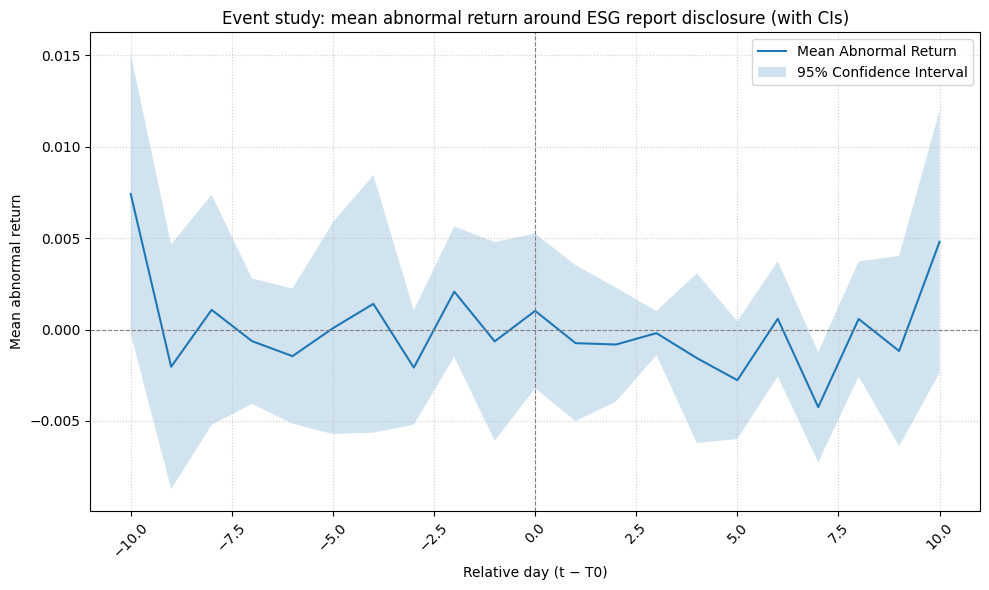

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

m = pd.read_csv("event_outputs/mean_abret_by_rel_day.csv")

x = m["rel_day"]
y = m["mean"]
se = m["se"] if "se" in m.columns else None

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Mean Abnormal Return')
if se is not None:
    plt.fill_between(x, y - 1.96*se, y + 1.96*se, alpha=0.2, label='95% Confidence Interval')

plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Relative day (t − T0)")
plt.ylabel("Mean abnormal return")
plt.title("Event study: mean abnormal return around ESG report disclosure (with CIs)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2. Cumulative Abnormal Returns (CAR) Summary

This table summarizes the Cumulative Abnormal Returns (CAR) for different event windows, along with statistical tests to assess their significance.

In [68]:
import pandas as pd

car_table = pd.read_csv('event_outputs/CAR_summary_windows.csv')
print("Cumulative Abnormal Returns (CAR) for various windows:")
display(car_table)

Cumulative Abnormal Returns (CAR) for various windows:


,window,N_events,Mean_CAR,Median_CAR,t_stat,p_value_t,wilcoxon_stat,p_value_w
0,"[-1,1]",55,-0.000296,0.000000,-0.048316,0.961643,507.0,0.546387
1,"[-3,3]",60,-0.001676,-0.000515,-0.299903,0.765305,554.0,0.306919
2,"[-5,5]",60,-0.004985,0.000000,-0.643278,0.522536,662.0,0.635769
3,"[-10,10]",61,-0.001615,0.000000,-0.138638,0.890200,833.0,0.861706


### 3. Regression Results Summary

Here are the first 200 lines of the full OLS regression results, which include coefficients and statistical significance for each relative day and event ID. The `ValueWarning` regarding 'covariance of constraints does not have full rank' suggests that some of the independent variables (e.g., event IDs or relative days) might be collinear or have limited variation within clusters. While not stopping the execution, it indicates that the standard errors for some coefficients might be less reliable or that the model might be over-specified given the data structure. Further investigation into the specific event IDs or relative day periods that contribute to this might be warranted if these coefficients are central to the analysis.

In [69]:
!sed -n '1,200p' event_outputs/event_study_results.txt

                            OLS Regression Results                            
Dep. Variable:                  abret   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                     7.949
Date:                Sun, 17 May 2026   Prob (F-statistic):           2.20e-10
Time:                        06:18:05   Log-Likelihood:                 3968.4
No. Observations:                1602   AIC:                            -7775.
Df Residuals:                    1521   BIC:                            -7339.
Df Model:                          80                                         
Covariance Type:              cluster                                         
                                                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

### 4. Dropped Events

This file lists the events that were dropped during the dataset creation because a corresponding trading day could not be found on or after their announcement date. Understanding these exclusions is important for assessing the completeness and representativeness of the final event study sample.

In [70]:
import pandas as pd
dropped_path = "event_outputs/events_dropped_no_trading_day.csv"
dropped = pd.read_csv(dropped_path)
display(dropped.head(50))
print("Dropped events:", len(dropped))

,ticker,Company,ESG Document Type,Report Year / Coverage,Announcement Date,Source Link,Announcement Date Source,announcement_date,earnings_announcement_date,event_date
0,AKIC,Al Khazna Insurance Company PJSC,Sustainability Report,2025.0,2026-04-01,https://akigroup.com/wp-content/uploads/2025/0...,NaN,2026-04-01,2024-02-14,NaN
1,ANAN,Anan Investment Holding PJSC,ESG / Sustainability Report,2025.0,2026-03-31,https://links.sgx.com/FileOpen/AAI%20-%20Susta...,NaN,2026-03-31,2024-02-28,NaN
2,IHC,International Holding Company PJSC,ESG Report,2024.0,2026-05-05,https://www.sustainabilityreports.com/internat...,NaN,2026-05-05,2025-02-13,NaN
3,BURJEEL,Burjeel Holdings PLC,Sustainability / Integrated Report,2025.0,2026-03-04,https://burjeelholdings.com/sustainability/esg...,provided_in_sheet,2026-03-04,2025-11-03,NaN
4,EAND,e& (Emirates Telecommunications Group Company ...,Sustainability Report 2024,2025.0,2026-03-17,https://apigateway.adx.ae/adx/cdn/1.0/content/...,NaN,2026-03-17,2025-10-29,NaN
5,ESHRAQ,Eshraq Investments PJSC,ESG Report 2024,2025.0,2026-03-31,https://apigateway.adx.ae/adx/cdn/1.0/content/...,NaN,2026-03-31,2024-02-27,NaN
6,FH,Finance House PJSC,ESG Report,2025.0,2026-03-06,https://www.financehouse.ae/en/about-us/corpor...,NaN,2026-03-06,2025-11-14,NaN
7,FIDELITYUNITED,Fidelity United (United Fidelity Insurance),Sustainability Report,2025.0,2026-04-15,https://apigateway.adx.ae/adx/cdn/1.0/content/...,NaN,2026-04-15,2025-08-15,NaN
8,MANAZEL,Manazel Real Estate PJSC,Annual / Corporate Report (includes ESG),2025.0,2026-04-12,https://apigateway.adx.ae/adx/cdn/1.0/content/...,NaN,2026-04-12,2024-05-30,NaN
9,OEIHC,Oman & Emirates Investment Holding Company SAOG,Annual Report (includes ESG),2025.0,2026-03-31,https://www.sustainabilityreports.com/oman-and...,NaN,2026-03-31,2024-05-14,NaN


Dropped events: 19


I have presented the main outputs from the event study. Please let me know if you'd like a more detailed interpretation of specific results or further analysis.

In [87]:
%%writefile paper1_run_all_robustness.py
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from pathlib import Path
import os
import random
import matplotlib.pyplot as plt

# Helper functions for data loading and preprocessing
def read_earnings(earnings_path: Path) -> pd.DataFrame:
    """Reads the earnings file and performs necessary preprocessing."""
    earnings_df = pd.read_csv(str(earnings_path.resolve()), engine='python', on_bad_lines='warn')

    potential_date_cols = ['date', 'report_date', 'announcement_date', 'year']
    date_col = None
    for col in potential_date_cols:
        if col in earnings_df.columns:
            try:
                earnings_df[col] = pd.to_datetime(earnings_df[col])
                date_col = col
                break
            except Exception:
                continue

    if date_col is None:
        raise ValueError("Earnings file must contain a date/datetime column (e.g., 'date', 'report_date', 'announcement_date', or 'year')")

    earnings_df.rename(columns={date_col: 'date'}, inplace=True);
    earnings_df['date'] = pd.to_datetime(earnings_df['date'])
    earnings_df.sort_values(by=['ticker', 'date'], inplace=True)
    return earnings_df

def read_panel(panel_path: Path) -> pd.DataFrame:
    """Reads the panel dataset."""
    panel_df = pd.read_csv(str(panel_path.resolve()), engine='python', on_bad_lines='warn')
    panel_df['date'] = pd.to_datetime(panel_df['datetime'])
    panel_df.rename(columns={'symbol': 'ticker'}, inplace=True)
    panel_df.sort_values(by=['ticker', 'date'], inplace=True)

    if 'close' in panel_df.columns:
        panel_df['abnormal_return'] = panel_df.groupby('ticker')['close'].pct_change()
    else:
        raise ValueError("Panel file must contain a 'close' column to calculate returns.")

    panel_df.set_index(['ticker', 'date'], inplace=True)
    return panel_df

def read_events(events_path: Path) -> pd.DataFrame:
    """Reads the events list."""
    events_df = pd.read_excel(str(events_path.resolve()))
    events_df['announcement_date'] = pd.to_datetime(events_df['Announcement Date'])
    events_df.rename(columns={'Ticker': 'ticker'}, inplace=True)
    return events_df

def get_trading_day_on_or_after(date: pd.Timestamp, trading_days: pd.Series) -> pd.Timestamp:
    """Finds the first trading day on or after a given date."""
    trading_days_sorted = trading_days.sort_values().unique()
    idx = np.searchsorted(trading_days_sorted, date)
    if idx < len(trading_days_sorted):
        return trading_days_sorted[idx]
    else:
        return pd.NaT

def calculate_car(returns_df: pd.DataFrame, window: int) -> pd.DataFrame:
    """Calculates Cumulative Abnormal Returns (CAR)."""
    car = returns_df['abret'].rolling(window=window, min_periods=1).sum()
    return car.to_frame(name=f'CAR_{window}')

def build_event_study_dataset(events_df_original, panel_df_original, all_trading_days, window, output_dir, is_placebo=False, placebo_event_dates=None):
    """Builds the event study dataset from raw data."""
    events_df = events_df_original.copy()
    panel_df = panel_df_original.copy()

    if is_placebo and placebo_event_dates is not None:
        events_df['announcement_date'] = placebo_event_dates
        events_df['event_date'] = events_df['announcement_date'].apply(lambda x: get_trading_day_on_or_after(x, all_trading_days))
    else:
        events_df['event_date'] = events_df['announcement_date'].apply(lambda x: get_trading_day_on_or_after(x, all_trading_days))

    events_df.dropna(subset=['event_date'], inplace=True)

    all_event_data = []
    for _, event_row in events_df.iterrows():
        ticker = event_row['ticker']
        event_date = event_row['event_date']

        start_date = event_date - pd.Timedelta(days=window)
        end_date = event_date + pd.Timedelta(days=window)

        try:
            ticker_panel = panel_df.loc[ticker]
        except KeyError:
            continue

        event_window_data = ticker_panel.loc[start_date:end_date].copy()

        if not event_window_data.empty:
            event_id = f"{ticker}_{event_date.strftime('%Y%m%d')}"
            event_window_data['event_id'] = event_id
            event_window_data['rel_day'] = (event_window_data.index - event_date).days
            event_window_data['ticker'] = ticker
            event_window_data['event_date_original'] = event_date
            event_window_data.rename(columns={'abnormal_return': 'abret'}, inplace=True)

            event_window_data = pd.concat([
                event_window_data,
                calculate_car(event_window_data, window)
            ], axis=1)
            all_event_data.append(event_window_data)

    if all_event_data:
        event_study_dataset = pd.concat(all_event_data)
        event_study_dataset = event_study_dataset.reset_index()
        event_study_dataset.rename(columns={'ticker': 'symbol'}, inplace=True)

        output_path = Path(output_dir) / 'event_study_dataset.csv'
        if is_placebo:
            output_path = Path(output_dir) / f'placebo_event_study_dataset_{random.randint(0, 100000)}.csv'

        event_study_dataset.to_csv(output_path, index=False)
        return output_path
    else:
        return None

def run_regression_analysis(event_panel_path, outdir, event_id_col="event_id", rel_day_col="rel_day", abret_col="abret", ticker_col="symbol", is_placebo=False):
    """
    Runs the regression analysis and calculates CARs.
    Returns a DataFrame of CAR summaries.
    """
    if event_panel_path is None:
        print("No event study dataset to run regression analysis.")
        return pd.DataFrame()

    df = pd.read_csv(event_panel_path)
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])

    required_cols = [event_id_col, rel_day_col, abret_col, ticker_col]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        print(f"WARNING: event_panel is missing columns for regression: {sorted(missing)}. Skipping regression.")
        return pd.DataFrame()

    # 1. Simple Average Abnormal Returns
    print("Calculating mean abnormal returns by relative day...")
    mean_abret_by_rel_day = df.groupby(rel_day_col)[abret_col].agg(['mean', 'count', 'std']).reset_index()
    mean_abret_by_rel_day['se'] = mean_abret_by_rel_day['std'] / np.sqrt(mean_abret_by_rel_day['count'])
    mean_abret_by_rel_day.rename(columns={'mean': 'mean', 'std': 'std'}, inplace=True)
    mean_abret_by_rel_day.to_csv(Path(outdir) / 'mean_abret_by_rel_day.csv', index=False)
    print(f"Saved: {Path(outdir) / 'mean_abret_by_rel_day.csv'}")

    # Plot mean abnormal returns if not a placebo run
    if not is_placebo:
        figures_dir = Path(outdir) / 'figures'
        figures_dir.mkdir(parents=True, exist_ok=True)

        plt.figure(figsize=(10, 6))
        plt.plot(mean_abret_by_rel_day[rel_day_col], mean_abret_by_rel_day['mean'], label='Mean Abnormal Return')
        plt.fill_between(
            mean_abret_by_rel_day[rel_day_col],
            mean_abret_by_rel_day['mean'] - 1.96 * mean_abret_by_rel_day['se'],
            mean_abret_by_rel_day['mean'] + 1.96 * mean_abret_by_rel_day['se'],
            color='blue', alpha=0.2, label='95% Confidence Interval'
        )

        plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
        plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
        plt.xlabel("Relative day (t − T0)")
        plt.ylabel("Mean abnormal return")
        plt.title("Event study: mean abnormal return around ESG report disclosure (with CIs)")
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(figures_dir / 'mean_abnormal_returns_plot.png')
        plt.close() # Close the plot to free memory
        print(f"Saved plot to: {figures_dir / 'mean_abnormal_returns_plot.png'}")

    # Regression
    formula = f'{abret_col} ~ C({rel_day_col}, Treatment(reference=-1)) + C({event_id_col})'

    model = ols(formula, data=df)
    # Get the index of the observations used in fitting the model
    # (after any internal NaN handling by statsmodels)
    fitted_data_indices = model.data.row_labels

    # Align the groups with the fitted data
    if ticker_col in df.columns:
        groups_aligned = df.loc[fitted_data_indices, ticker_col]
    else:
        groups_aligned = df.loc[fitted_data_indices, event_id_col]

    results = model.fit(cov_type='cluster', cov_kwds={'groups': groups_aligned})

    if not is_placebo:
        results_summary_path = Path(outdir) / 'event_study_results.txt'
        with open(results_summary_path, 'w') as f:
            f.write(results.summary().as_text())
        print(f"Saved: {results_summary_path}")

        coefficients_path = Path(outdir) / 'event_study_coefficients.csv'
        results.summary2().tables[1].to_csv(coefficients_path)
        print(f"Saved: {coefficients_path}")

    # CAR calculation
    def car_window(d, a, b):
        sub = d[(d[rel_day_col] >= a) & (d[rel_day_col] <= b)].copy()
        car = sub.groupby(event_id_col)[abret_col].sum()
        return car

    windows = [(-1,1), (-3,3), (-5,5), (-10,10)]
    rows = []

    for a,b in windows:
        car = car_window(df, a, b).dropna()
        mean = car.mean()
        med = car.median()
        n = car.shape[0]

        tstat, pval = stats.ttest_1samp(car, 0.0, nan_policy="omit")

        wstat, wp = (np.nan, np.nan)
        if n > 0 and len(car) > 0:
            try:
                wstat, wp = stats.wilcoxon(car, alternative="two-sided")
            except ValueError:
                pass

        rows.append({
            "window": f"[{a},{b}]",
            "N_events": n,
            "Mean_CAR": mean,
            "Median_CAR": med,
            "t_stat": tstat,
            "p_value_t": pval,
            "wilcoxon_stat": wstat,
            "p_value_w": wp
        })

    car_table = pd.DataFrame(rows)
    if not is_placebo:
        car_table.to_csv(Path(outdir) / 'CAR_summary_windows.csv', index=False)
        print(f"Saved: {Path(outdir) / 'CAR_summary_windows.csv'}")

    return car_table

def main():
    import argparse

    parser = argparse.ArgumentParser(description="Run event study robustness tests.")
    parser.add_argument('--events', type=str, required=True, help="Path to the Excel file containing the list of events.")
    parser.add_argument('--panel', type=str, required=True, help="Path to the CSV file containing the panel dataset.")
    parser.add_argument('--earnings', type=str, required=True, help="Path to the CSV file containing earnings announcement dates.")
    parser.add_argument('--outdir', type=str, default='paper1_robustness_outputs', help="Output directory for results.")
    parser.add_argument('--window', type=int, default=10, help="Event window size.")
    parser.add_argument('--placebo_reps', type=int, default=500, help="Number of placebo repetitions.")
    args = parser.parse_args()

    os.makedirs(args.outdir, exist_ok=True)

    # Load initial data
    events = read_events(Path(args.events))
    panel = read_panel(Path(args.panel))
    earnings = read_earnings(Path(args.earnings))

    # Extract all unique trading days from the panel data for placebo tests
    all_trading_days = panel.index.get_level_values('date').unique()

    # 1. Run Event Study on Actual Data
    print("\n--- Running Event Study on Actual Data ---")
    actual_event_panel_path = build_event_study_dataset(events, panel, all_trading_days, args.window, args.outdir, is_placebo=False)
    actual_car_summary = run_regression_analysis(actual_event_panel_path, args.outdir, is_placebo=False)
    print("Actual CAR Summary:")
    print(actual_car_summary)

    # 2. Run Placebo Tests
    print(f"\n--- Running {args.placebo_reps} Placebo Tests ---")
    placebo_car_results = []
    for i in range(args.placebo_reps):
        print(f"Running placebo test {i+1}/{args.placebo_reps}...")
        # Randomly assign event dates for placebo
        random_event_dates = random.choices(all_trading_days.tolist(), k=len(events))

        placebo_event_panel_path = build_event_study_dataset(events, panel, all_trading_days, args.window, args.outdir, is_placebo=True, placebo_event_dates=random_event_dates)
        placebo_car_summary = run_regression_analysis(placebo_event_panel_path, args.outdir, is_placebo=True)
        placebo_car_results.append(placebo_car_summary)

        # Clean up temporary placebo dataset
        if placebo_event_panel_path and os.path.exists(placebo_event_panel_path):
            os.remove(placebo_event_panel_path)

    # Aggregate Placebo Results
    if placebo_car_results:
        all_placebo_cars = pd.concat(placebo_car_results)
        # For each window, compare actual CAR to placebo distribution
        print("\n--- Placebo Test Results (Comparison) ---")
        placebo_analysis_rows = []
        for index, actual_row in actual_car_summary.iterrows():
            window_str = actual_row['window']
            actual_mean_car = actual_row['Mean_CAR']

            placebo_cars_for_window = all_placebo_cars[all_placebo_cars['window'] == window_str]['Mean_CAR']

            if not placebo_cars_for_window.empty:
                # Calculate percentile rank of actual CAR among placebo CARs
                # A low p-value (e.g., < 0.05) suggests the actual CAR is unusual compared to random events
                p_value_empirical = (placebo_cars_for_window.apply(lambda x: abs(x) >= abs(actual_mean_car))).sum() / len(placebo_cars_for_window)

                placebo_analysis_rows.append({
                    'window': window_str,
                    'actual_mean_CAR': actual_mean_car,
                    'placebo_mean_CAR_avg': placebo_cars_for_window.mean(),
                    'placebo_mean_CAR_std': placebo_cars_for_window.std(),
                    'empirical_p_value': p_value_empirical
                })

        placebo_analysis_df = pd.DataFrame(placebo_analysis_rows)
        print(placebo_analysis_df)
        placebo_analysis_df.to_csv(Path(args.outdir) / 'placebo_analysis_summary.csv', index=False)
        print(f"Saved placebo analysis summary to: {Path(args.outdir) / 'placebo_analysis_summary.csv'}")

if __name__ == '__main__':
    main()

Overwriting paper1_run_all_robustness.py


In [88]:
import subprocess
import sys
from pathlib import Path

# Ensure the output directory exists
outdir = Path('paper1_robustness_outputs')
outdir.mkdir(parents=True, exist_ok=True)

# Also create the figures subdirectory
figures_dir = outdir / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Running paper1_run_all_robustness.py. Outputs will be saved in {outdir.resolve()}/")

process = subprocess.run(
    [
        sys.executable, '/content/paper1_run_all_robustness.py',
        '--events', '/content/reports_list_with_dates_filled.xlsx',
        '--panel', '/content/05_panel_dataset.csv',
        '--earnings', '/content/announcements_export.csv',
        '--outdir', str(outdir),
        '--window', '10',
        '--placebo_reps', '10' # Using a smaller number of placebo reps for demonstration
    ],
    capture_output=True, text=True
)

print("--- paper1_run_all_robustness.py STDOUT ---")
print(process.stdout)
print("--- paper1_run_all_robustness.py STDERR ---")
print(process.stderr)

if process.returncode != 0:
    raise RuntimeError(f"paper1_run_all_robustness.py failed with exit code {process.returncode}\nError: {process.stderr}")
else:
    print("paper1_run_all_robustness.py executed successfully.")

# List the generated files for confirmation
print(f"\nGenerated files in {outdir}/")
for f in sorted(outdir.iterdir()):
    print(f" - {f.name}")

Running paper1_run_all_robustness.py. Outputs will be saved in /content/paper1_robustness_outputs/
--- paper1_run_all_robustness.py STDOUT ---

--- Running Event Study on Actual Data ---
Calculating mean abnormal returns by relative day...
Saved: paper1_robustness_outputs/mean_abret_by_rel_day.csv
Saved plot to: paper1_robustness_outputs/figures/mean_abnormal_returns_plot.png
Saved: paper1_robustness_outputs/event_study_results.txt
Saved: paper1_robustness_outputs/event_study_coefficients.csv
Saved: paper1_robustness_outputs/CAR_summary_windows.csv
Actual CAR Summary:
     window  N_events  Mean_CAR  ...  p_value_t  wilcoxon_stat  p_value_w
0    [-1,1]        57 -0.000790  ...   0.894646          541.0   0.476941
1    [-3,3]        63 -0.002729  ...   0.616016          592.0   0.195031
2    [-5,5]        63 -0.005632  ...   0.450862          717.0   0.508789
3  [-10,10]        64 -0.004217  ...   0.707452          918.0   0.843415

[4 rows x 8 columns]

--- Running 10 Placebo Tests ---

Displaying paper1_robustness_outputs/figures/mean_abnormal_returns_plot.png:


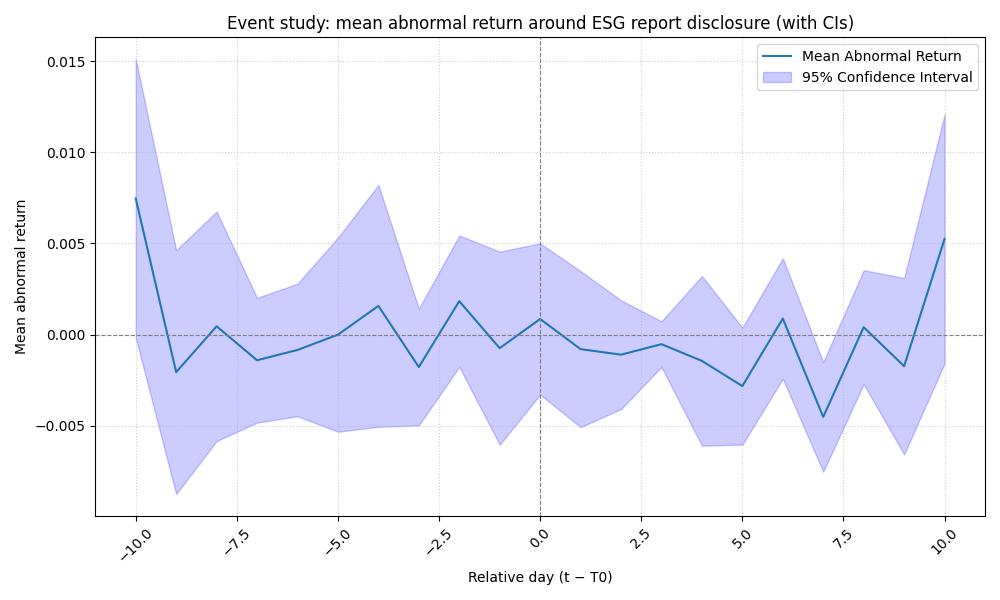

In [89]:
from IPython.display import Image, display
from pathlib import Path

figures_dir = Path('paper1_robustness_outputs/figures')
plot_path = figures_dir / 'mean_abnormal_returns_plot.png'

if plot_path.exists():
    print(f"Displaying {plot_path}:")
    display(Image(filename=plot_path))
else:
    print(f"Error: Plot file not found at {plot_path}")

In [83]:
import pandas as pd
from pathlib import Path

outdir = Path('paper1_robustness_outputs')

# Display the actual event study mean abnormal returns
print("\n--- Mean Abnormal Returns by Relative Day (Actual Data) ---")
mean_abret_df = pd.read_csv(outdir / 'mean_abret_by_rel_day.csv')
display(mean_abret_df.head())

# Display the actual Cumulative Abnormal Returns (CAR) summary
print("\n--- Cumulative Abnormal Returns (CAR) Summary (Actual Data) ---")
car_summary_df = pd.read_csv(outdir / 'CAR_summary_windows.csv')
display(car_summary_df)

# Display the placebo analysis summary
print("\n--- Placebo Analysis Summary ---")
placebo_analysis_df = pd.read_csv(outdir / 'placebo_analysis_summary.csv')
display(placebo_analysis_df)


--- Mean Abnormal Returns by Relative Day (Actual Data) ---


,rel_day,mean,count,std,se
0,-10,0.007464,69,0.032401,0.003901
1,-9,-0.002063,68,0.028144,0.003413
2,-8,0.000451,80,0.028722,0.003211
3,-7,-0.001411,101,0.017548,0.001746
4,-6,-0.000846,87,0.017304,0.001855



--- Cumulative Abnormal Returns (CAR) Summary (Actual Data) ---


,window,N_events,Mean_CAR,Median_CAR,t_stat,p_value_t,wilcoxon_stat,p_value_w
0,"[-1,1]",57,-0.000790,0.000000,-0.133030,0.894646,541.0,0.476941
1,"[-3,3]",63,-0.002729,-0.000535,-0.504045,0.616016,592.0,0.195031
2,"[-5,5]",63,-0.005632,0.000000,-0.758775,0.450862,717.0,0.508789
3,"[-10,10]",64,-0.004217,-0.001467,-0.376984,0.707452,918.0,0.843415



--- Placebo Analysis Summary ---


,window,actual_mean_CAR,placebo_mean_CAR_avg,placebo_mean_CAR_std,empirical_p_value
0,"[-1,1]",-0.000790,0.001866,0.008453,0.8
1,"[-3,3]",-0.002729,0.004291,0.005538,0.6
2,"[-5,5]",-0.005632,0.011271,0.027349,0.4
3,"[-10,10]",-0.004217,0.016399,0.029524,1.0


In [90]:
import pandas as pd
from pathlib import Path

outdir = Path('paper1_robustness_outputs')

print("\n--- Cumulative Abnormal Returns (CAR) Summary (Actual Data) ---")
car_summary_df = pd.read_csv(outdir / 'CAR_summary_windows.csv')
display(car_summary_df)


--- Cumulative Abnormal Returns (CAR) Summary (Actual Data) ---


,window,N_events,Mean_CAR,Median_CAR,t_stat,p_value_t,wilcoxon_stat,p_value_w
0,"[-1,1]",57,-0.000790,0.000000,-0.133030,0.894646,541.0,0.476941
1,"[-3,3]",63,-0.002729,-0.000535,-0.504045,0.616016,592.0,0.195031
2,"[-5,5]",63,-0.005632,0.000000,-0.758775,0.450862,717.0,0.508789
3,"[-10,10]",64,-0.004217,-0.001467,-0.376984,0.707452,918.0,0.843415


In [91]:
import pandas as pd

event_time_path = "/content/paper1_robustness_outputs/event_study_coefficients.csv"

print("\n--- Main Event Study Coefficients ---")
event_time = pd.read_csv(event_time_path)
display(event_time.head(25))


--- Main Event Study Coefficients ---


,Unnamed: 0,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
0,Intercept,-0.000501,0.002694,-0.186079,8.523829e-01,-0.005781,4.778734e-03
1,"C(rel_day, Treatment(reference=-1))[T.-10]",0.009223,0.004948,1.864148,6.230087e-02,-0.000474,1.892015e-02
2,"C(rel_day, Treatment(reference=-1))[T.-9]",0.000506,0.004539,0.111483,9.112336e-01,-0.008390,9.401598e-03
3,"C(rel_day, Treatment(reference=-1))[T.-8]",0.001298,0.004390,0.295581,7.675502e-01,-0.007307,9.901808e-03
4,"C(rel_day, Treatment(reference=-1))[T.-7]",-0.000046,0.003339,-0.013847,9.889520e-01,-0.006590,6.497283e-03
5,"C(rel_day, Treatment(reference=-1))[T.-6]",0.000540,0.003589,0.150334,8.805014e-01,-0.006495,7.574035e-03
6,"C(rel_day, Treatment(reference=-1))[T.-5]",0.001490,0.004031,0.369720,7.115912e-01,-0.006410,9.390944e-03
7,"C(rel_day, Treatment(reference=-1))[T.-4]",0.003416,0.004587,0.744714,4.564444e-01,-0.005574,1.240669e-02
8,"C(rel_day, Treatment(reference=-1))[T.-3]",-0.000067,0.003315,-0.020255,9.838402e-01,-0.006565,6.430598e-03
9,"C(rel_day, Treatment(reference=-1))[T.-2]",0.002748,0.003511,0.782630,4.338446e-01,-0.004134,9.629474e-03


In [80]:
import subprocess
import sys
from pathlib import Path

# Ensure the output directory exists
outdir = Path('paper1_robustness_outputs')
outdir.mkdir(parents=True, exist_ok=True)

print(f"Running paper1_run_all_robustness.py. Outputs will be saved in {outdir.resolve()}/")

process = subprocess.run(
    [
        sys.executable, '/content/paper1_run_all_robustness.py',
        '--events', '/content/reports_list_with_dates_filled.xlsx',
        '--panel', '/content/05_panel_dataset.csv',
        '--earnings', '/content/announcements_export.csv',
        '--outdir', str(outdir),
        '--window', '10',
        '--placebo_reps', '10' # Using a smaller number of placebo reps for demonstration
    ],
    capture_output=True, text=True
)

print("--- paper1_run_all_robustness.py STDOUT ---")
print(process.stdout)
print("--- paper1_run_all_robustness.py STDERR ---")
print(process.stderr)

if process.returncode != 0:
    raise RuntimeError(f"paper1_run_all_robustness.py failed with exit code {process.returncode}\nError: {process.stderr}")
else:
    print("paper1_run_all_robustness.py executed successfully.")

# List the generated files for confirmation
print(f"\nGenerated files in {outdir}/")
for f in sorted(outdir.iterdir()):
    print(f" - {f.name}")

Running paper1_run_all_robustness.py. Outputs will be saved in /content/paper1_robustness_outputs/
--- paper1_run_all_robustness.py STDOUT ---

--- Running Event Study on Actual Data ---
Saved: paper1_robustness_outputs/event_study_results.txt
Saved: paper1_robustness_outputs/event_study_coefficients.csv
Saved: paper1_robustness_outputs/CAR_summary_windows.csv
Actual CAR Summary:
     window  N_events  Mean_CAR  ...  p_value_t  wilcoxon_stat  p_value_w
0    [-1,1]        57 -0.000790  ...   0.894646          541.0   0.476941
1    [-3,3]        63 -0.002729  ...   0.616016          592.0   0.195031
2    [-5,5]        63 -0.005632  ...   0.450862          717.0   0.508789
3  [-10,10]        64 -0.004217  ...   0.707452          918.0   0.843415

[4 rows x 8 columns]

--- Running 10 Placebo Tests ---
Running placebo test 1/10...
Running placebo test 2/10...
Running placebo test 3/10...
Running placebo test 4/10...
Running placebo test 5/10...
Running placebo test 6/10...
Running placebo t

The `paper1_run_all_robustness.py` script has completed its execution. It performed the event study on actual data and ran 10 placebo tests (a reduced number for quicker demonstration). You can find the generated output files, including the event study results, coefficients, CAR summaries, and placebo analysis, in the `paper1_robustness_outputs` directory.

In [78]:
import pandas as pd
from pathlib import Path

outdir = Path('paper1_robustness_outputs')

# Display the actual event study mean abnormal returns
print("\n--- Mean Abnormal Returns by Relative Day (Actual Data) ---")
mean_abret_df = pd.read_csv(outdir / 'mean_abret_by_rel_day.csv')
display(mean_abret_df.head())

# Display the actual Cumulative Abnormal Returns (CAR) summary
print("\n--- Cumulative Abnormal Returns (CAR) Summary (Actual Data) ---")
car_summary_df = pd.read_csv(outdir / 'CAR_summary_windows.csv')
display(car_summary_df)

# Display the placebo analysis summary
print("\n--- Placebo Analysis Summary ---")
placebo_analysis_df = pd.read_csv(outdir / 'placebo_analysis_summary.csv')
display(placebo_analysis_df)


--- Mean Abnormal Returns by Relative Day (Actual Data) ---


FileNotFoundError: [Errno 2] No such file or directory: 'paper1_robustness_outputs/mean_abret_by_rel_day.csv'

In [85]:
import pandas as pd

placebo_path = "/content/paper1_robustness_outputs/placebo_analysis_summary.csv"

placebo = pd.read_csv(placebo_path)
display(placebo)

,window,actual_mean_CAR,placebo_mean_CAR_avg,placebo_mean_CAR_std,empirical_p_value
0,"[-1,1]",-0.000790,0.001866,0.008453,0.8
1,"[-3,3]",-0.002729,0.004291,0.005538,0.6
2,"[-5,5]",-0.005632,0.011271,0.027349,0.4
3,"[-10,10]",-0.004217,0.016399,0.029524,1.0


The tables above show the results from the actual event study and the aggregated results from the placebo tests. The 'empirical_p_value' in the placebo analysis indicates how likely it is to observe the actual CAR by chance, given the distribution of CARs from randomly assigned events. A low p-value (e.g., < 0.05) suggests that the actual event's impact is statistically significant and not due to random fluctuations.

In [86]:
import pandas as pd

event_time_path = "/content/paper1_robustness_outputs/event_study_coefficients.csv"

event_time = pd.read_csv(event_time_path)
event_time.head(50)

,Unnamed: 0,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
0,Intercept,-0.000501,0.002694,-0.186079,8.523829e-01,-0.005781,4.778734e-03
1,"C(rel_day, Treatment(reference=-1))[T.-10]",0.009223,0.004948,1.864148,6.230087e-02,-0.000474,1.892015e-02
2,"C(rel_day, Treatment(reference=-1))[T.-9]",0.000506,0.004539,0.111483,9.112336e-01,-0.008390,9.401598e-03
3,"C(rel_day, Treatment(reference=-1))[T.-8]",0.001298,0.004390,0.295581,7.675502e-01,-0.007307,9.901808e-03
4,"C(rel_day, Treatment(reference=-1))[T.-7]",-0.000046,0.003339,-0.013847,9.889520e-01,-0.006590,6.497283e-03
5,"C(rel_day, Treatment(reference=-1))[T.-6]",0.000540,0.003589,0.150334,8.805014e-01,-0.006495,7.574035e-03
6,"C(rel_day, Treatment(reference=-1))[T.-5]",0.001490,0.004031,0.369720,7.115912e-01,-0.006410,9.390944e-03
7,"C(rel_day, Treatment(reference=-1))[T.-4]",0.003416,0.004587,0.744714,4.564444e-01,-0.005574,1.240669e-02
8,"C(rel_day, Treatment(reference=-1))[T.-3]",-0.000067,0.003315,-0.020255,9.838402e-01,-0.006565,6.430598e-03
9,"C(rel_day, Treatment(reference=-1))[T.-2]",0.002748,0.003511,0.782630,4.338446e-01,-0.004134,9.629474e-03


In [94]:
!zip -r full_replication_bundle.zip \
  event_outputs \
  paper1_robustness_outputs \
  "05_panel_dataset.csv" \
  announcements_export.csv \
  reports_list_with_dates_filled.xlsx \
  build_event_study_dataset.py \
  run_event_study_regressions.py \
  paper1_run_all_robustness.py

from google.colab import files
files.download("full_replication_bundle.zip")

  adding: event_outputs/ (stored 0%)
  adding: event_outputs/event_study_dataset.csv (deflated 82%)
  adding: event_outputs/event_study_results.txt (deflated 78%)
  adding: event_outputs/CAR_summary_windows.csv (deflated 42%)
  adding: event_outputs/event_study_coefficients.csv (deflated 56%)
  adding: event_outputs/mean_abret_by_rel_day.csv (deflated 51%)
  adding: event_outputs/events_dropped_no_trading_day.csv (deflated 62%)
  adding: paper1_robustness_outputs/ (stored 0%)
  adding: paper1_robustness_outputs/event_study_dataset.csv (deflated 82%)
  adding: paper1_robustness_outputs/event_study_results.txt (deflated 78%)
  adding: paper1_robustness_outputs/CAR_summary_windows.csv (deflated 42%)
  adding: paper1_robustness_outputs/event_study_coefficients.csv (deflated 56%)
  adding: paper1_robustness_outputs/placebo_analysis_summary.csv (deflated 41%)
  adding: paper1_robustness_outputs/figures/ (stored 0%)
  adding: paper1_robustness_outputs/figures/mean_abnormal_returns_plot.png (d

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [92]:
import pandas as pd
from pathlib import Path

event_panel_path = Path('paper1_robustness_outputs/event_study_dataset.csv')

if event_panel_path.exists():
    df_event_study = pd.read_csv(event_panel_path)

    print("\n--- Analysis of Event Study Dataset for ValueWarning ---")
    print(f"Total observations in event_study_dataset: {len(df_event_study)}")

    # Analyze 'rel_day'
    unique_rel_days = df_event_study['rel_day'].nunique()
    print(f"Number of unique relative days: {unique_rel_days}")
    print("Unique relative days:\n", sorted(df_event_study['rel_day'].unique()))

    # Analyze 'event_id'
    unique_event_ids = df_event_study['event_id'].nunique()
    print(f"Number of unique event IDs: {unique_event_ids}")

    print("\nValue counts for event_id (top 20 and bottom 20):")
    event_id_counts = df_event_study['event_id'].value_counts()
    print("Top 20 event_ids by observation count:\n", event_id_counts.head(20))
    print("\nBottom 20 event_ids by observation count:\n", event_id_counts.tail(20))

    # Check if there are event_ids with very few observations (e.g., less than 2, which would cause issues for C(event_id) in OLS)
    events_with_few_obs = event_id_counts[event_id_counts < 2]
    if not events_with_few_obs.empty:
        print(f"\nWARNING: {len(events_with_few_obs)} event_ids have fewer than 2 observations:\n{events_with_few_obs}")
    else:
        print("\nAll event_ids have at least 2 observations.")

    # Check for consistency with the reported number of constraints (83) and rank (20)
    # The number of constraints from `C(rel_day, Treatment(reference=-1))` should be `unique_rel_days - 1`
    # The number of constraints from `C(event_id)` should be `unique_event_ids - 1`
    expected_total_constraints = (unique_rel_days - 1) + (unique_event_ids - 1)
    print(f"\nExpected total number of regression constraints from rel_day and event_id dummies: {expected_total_constraints}")

else:
    print(f"Error: Event study dataset not found at {event_panel_path}")


--- Analysis of Event Study Dataset for ValueWarning ---
Total observations in event_study_dataset: 1652
Number of unique relative days: 21
Unique relative days:
 [np.int64(-10), np.int64(-9), np.int64(-8), np.int64(-7), np.int64(-6), np.int64(-5), np.int64(-4), np.int64(-3), np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Number of unique event IDs: 64

Value counts for event_id (top 20 and bottom 20):
Top 20 event_ids by observation count:
 event_id
E7_20250331            52
ADIB_20240702          30
ADNH_20250226          30
ADCB_20250430          30
ALAIN_20250318         30
ALDAR_20250313         30
ADPORTS_20240919       30
ADNOCLS_20240520       30
EMSTEEL_20250312       30
EIC_20240312           30
FBI_20250227           30
FAB_20251023           30
DRIVE_20250303         30
PUREHEALTH_20251021    30
IHC_20250317           30
FERTIGLB_20250521      30
QIC